# 02 — Toronto Neighbourhood Political Clustering: Model Exploration

Inspired by the [SF Chronicle's California political groups project](https://www.sfchronicle.com/projects/2026/california-political-groups/),
we cluster Toronto's 585 census tracts based on their voting behaviour across three recent elections:
the **2023 mayoral race**, the **2025 Ontario provincial election**, and the **2025 federal election**.

**Key design choices:**
- Features are **city-relative deviations** (tract minus citywide average, in percentage points) — interpretable and centred
- **Block weighting** equalises the contribution of each election; without it, the federal election (highest turnout, most spread) would dominate PCA
- **PCA** is used for clustering (deterministic, distance-preserving); UMAP is kept as a visualisation layer only
- A **riding-residual diagnostic** tests whether the clusters reflect genuine neighbourhood character or are primarily an artefact of riding-level electoral effects

**Where this fits in the pipeline:** this notebook does the actual model search -- every representation, weighting, and robustness check that leads to the adopted model, **8F** (a 50/50 blend of city-relative and within-riding-relative features, §8F below). It ends by saving that model's tract-level assignment to disk. `03_cluster_interpretation.ipynb` loads that file directly to interpret and name the five groups, and `04_process_ct_to_cluster.ipynb` loads it again to build the frontend's data files -- neither notebook re-runs this search.

In [1]:
import json
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import fcluster, linkage
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import umap
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
ROOT = Path("../..")
MAP_DIR    = ROOT / "analysis/toronto_election_turnout/data/archive/interpolation/map"
RIDING_DIR = ROOT / "analysis/toronto_election_turnout/data/archive/elections/raw"
OUT_ROOT   = ROOT / "data/clustering_neighbourhoods"
PROFILES_DIR = OUT_ROOT / "profiles"   # reusable GeoPackages and CSVs
FIGURES_DIR  = OUT_ROOT / "figures"    # publication-quality PNGs
EXPLORE_DIR  = OUT_ROOT / "explore"    # exploratory outputs and diagnostics
for d in [PROFILES_DIR, FIGURES_DIR, EXPLORE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

# Each block = turnout + vote shares for one election.
# Block weighting will standardise within each block then scale it to unit total variance,
# so no election dominates PCA regardless of its raw variance.
ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,   # 7 features
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,  # 6 features
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,   # 6 features
}

N_CLUSTERS_RANGE = [4, 5, 6, 7]
K_CHOSEN     = 5          # updated after silhouette analysis in §4
RANDOM_STATE = 42
PALETTE = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653", "#a8dadc"]

## 1. Data Loading & Feature Extraction

Each GeoJSON has a `party_votes` / `candidate_votes` property stored as a nested JSON object.
Vote **share** for each candidate/party is `estimated_votes / estimated_valid_candidate_votes`,
so shares sum to 1 within each election. The `other` bucket absorbs every minor candidate
not named above.

Citywide averages are population-weighted (by `estimated_valid_candidate_votes`) so they
reflect the true city-level result, not an unweighted tract mean.

In [3]:
def _parse_json(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):  return json.loads(val) if val else {}
    return {}

def load_gdf(filename):
    gdf = gpd.read_file(MAP_DIR / filename)
    for col in ["party_votes", "candidate_votes", "top_candidates"]:
        if col in gdf.columns:
            gdf[col] = gdf[col].apply(_parse_json)
    return gdf

mun_gdf  = load_gdf("municipal_2023_mayor_ct_map.geojson")
prov_gdf = load_gdf("provincial_2025_ct_map.geojson")
fed_gdf  = load_gdf("federal_2025_ct_map.geojson")
print(f"Municipal CTs:  {len(mun_gdf)}")
print(f"Provincial CTs: {len(prov_gdf)}")
print(f"Federal CTs:    {len(fed_gdf)}")

Municipal CTs:  585
Provincial CTs: 585
Federal CTs:    585


In [4]:
def _safe_share(votes, total):
    return votes / total if total > 0 else 0.0

# Turnout denominator: Canadian citizens aged 18+ (`estimated_participation_citizen_18plus`),
# not registered electors (`estimated_turnout`, still present in these files for reference/
# diagnostic use only -- see `analysis/toronto_election_turnout/09_final_synthesis.ipynb` §1).
# Registered-elector counts on record are themselves a product of list-maintenance practices
# (which vary by election and over time) rather than a stable measure of the eligible
# population, so they under/over-state turnout in ways that don't reflect real neighbourhood
# participation -- the revised turnout pipeline's own validation (same notebook) found the
# citizen-based rate tracks each election's published citywide turnout more closely.
def extract_mun_features(row):
    cvotes = row["candidate_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"mun_{k}": _safe_share(cvotes.get(v, 0.0), total)
              for k, v in MUN_CANDIDATE_KEYS.items()}
    shares["mun_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["mun_turnout"] = row["estimated_participation_citizen_18plus"]
    return shares

def extract_prov_features(row):
    pvotes = row["party_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"prov_{k}": _safe_share(pvotes.get(v, 0.0), total)
              for k, v in PROV_PARTY_KEYS.items()}
    shares["prov_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["prov_turnout"] = row["estimated_participation_citizen_18plus"]
    return shares

def extract_fed_features(row):
    pvotes = row["party_votes"]
    total  = row["estimated_valid_candidate_votes"]
    shares = {f"fed_{k}": _safe_share(pvotes.get(v, 0.0), total)
              for k, v in FED_PARTY_KEYS.items()}
    shares["fed_other"]   = max(0.0, 1.0 - sum(shares.values()))
    shares["fed_turnout"] = row["estimated_participation_citizen_18plus"]
    return shares

with tqdm(total=3, desc="Extracting features") as pbar:
    mun_feats  = pd.DataFrame([extract_mun_features(r)  for _, r in mun_gdf.iterrows()],  index=mun_gdf["ct_id"])
    pbar.update()
    prov_feats = pd.DataFrame([extract_prov_features(r) for _, r in prov_gdf.iterrows()], index=prov_gdf["ct_id"])
    pbar.update()
    fed_feats  = pd.DataFrame([extract_fed_features(r)  for _, r in fed_gdf.iterrows()],  index=fed_gdf["ct_id"])
    pbar.update()

raw_df = mun_feats.join(prov_feats, how="inner").join(fed_feats, how="inner")[ALL_COLS]

n_nan = raw_df.isna().sum().sum()
if n_nan > 0:
    print(f"Imputing {n_nan} NaN value(s) with column mean")
    raw_df = raw_df.fillna(raw_df.mean())

geom_df = mun_gdf.set_index("ct_id")[["geometry"]]
raw_gdf = gpd.GeoDataFrame(
    raw_df.join(geom_df, how="inner").reset_index(),
    geometry="geometry", crs=mun_gdf.crs,
)
print(f"\nFinal dataset: {len(raw_gdf)} census tracts × {len(ALL_COLS)} features")

# Flag CTs where no named-party votes were recorded in ≥1 election.
# Interpolation returns 0 for all named parties, so 'other' absorbs 100%.
# These are excluded from K-means fitting and assigned to the nearest centroid post-hoc.
_anom = (raw_gdf["mun_other"] >= 0.99) | (raw_gdf["prov_other"] >= 0.99) | (raw_gdf["fed_other"] >= 0.99)
anomaly_mask = _anom.values   # numpy bool array, len = n_tracts
n_anom = anomaly_mask.sum()
if n_anom:
    print(f"Data anomalies: {n_anom} CT(s) with no named-party data in ≥1 election "
          f"({raw_gdf.loc[_anom, 'ct_id'].values})")
    print("  → excluded from K-means fitting; assigned to nearest centroid post-hoc")
else:
    print("No data anomalies detected")

raw_gdf[ALL_COLS].describe().round(3)

Extracting features:   0%|          | 0/3 [00:00<?, ?it/s]

Imputing 6 NaN value(s) with column mean

Final dataset: 585 census tracts × 19 features
Data anomalies: 2 CT(s) with no named-party data in ≥1 election (['5350006.00' '5350205.00'])
  → excluded from K-means fitting; assigned to nearest centroid post-hoc


,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,prov_pc,prov_ndp,prov_liberal,prov_green,prov_other,fed_turnout,fed_liberal,fed_conservative,fed_ndp,fed_green,fed_other
count,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000,585.000
mean,0.389,0.367,0.319,0.090,0.049,0.045,0.130,0.475,0.351,0.221,0.382,0.027,0.019,0.704,0.579,0.340,0.064,0.007,0.011
std,0.104,0.115,0.095,0.034,0.017,0.038,0.074,0.092,0.142,0.200,0.109,0.008,0.046,0.099,0.072,0.102,0.060,0.006,0.058
min,0.102,0.000,0.000,0.000,0.000,0.000,0.038,0.221,0.000,0.000,0.000,0.000,0.000,0.477,0.000,0.000,0.000,0.000,0.000
25%,0.314,0.282,0.249,0.059,0.036,0.023,0.094,0.410,0.224,0.057,0.298,0.022,0.007,0.634,0.540,0.264,0.027,0.000,0.000
50%,0.374,0.353,0.310,0.097,0.048,0.037,0.116,0.473,0.361,0.092,0.384,0.026,0.014,0.697,0.586,0.344,0.036,0.008,0.006
75%,0.462,0.450,0.372,0.114,0.060,0.052,0.149,0.536,0.460,0.403,0.457,0.031,0.020,0.768,0.628,0.416,0.078,0.011,0.011
max,0.827,0.777,0.611,0.180,0.105,0.245,1.000,0.973,0.672,0.798,0.638,0.051,1.000,1.212,0.706,0.632,0.318,0.040,1.000


In [5]:
# ── Citywide averages (vote-weighted) ────────────────────────────────────────
citywide = {}

mun_valid = mun_gdf["estimated_valid_candidate_votes"]
for k, v in MUN_CANDIDATE_KEYS.items():
    citywide[f"mun_{k}"] = (
        mun_gdf["candidate_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / mun_valid.sum()
    )
citywide["mun_other"]   = max(0.0, 1.0 - sum(citywide[f"mun_{k}"] for k in MUN_CANDIDATE_KEYS))
citywide["mun_turnout"] = (
    (mun_gdf["estimated_participation_citizen_18plus"] * mun_gdf["citizen_canadian_18over"]).sum()
    / mun_gdf["citizen_canadian_18over"].sum()
)

prov_valid = prov_gdf["estimated_valid_candidate_votes"]
for k, v in PROV_PARTY_KEYS.items():
    citywide[f"prov_{k}"] = (
        prov_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / prov_valid.sum()
    )
citywide["prov_other"]   = max(0.0, 1.0 - sum(citywide[f"prov_{k}"] for k in PROV_PARTY_KEYS))
citywide["prov_turnout"] = (
    (prov_gdf["estimated_participation_citizen_18plus"] * prov_gdf["citizen_canadian_18over"]).sum()
    / prov_gdf["citizen_canadian_18over"].sum()
)

fed_valid = fed_gdf["estimated_valid_candidate_votes"]
for k, v in FED_PARTY_KEYS.items():
    citywide[f"fed_{k}"] = (
        fed_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / fed_valid.sum()
    )
citywide["fed_other"]   = max(0.0, 1.0 - sum(citywide[f"fed_{k}"] for k in FED_PARTY_KEYS))
citywide["fed_turnout"] = (
    (fed_gdf["estimated_participation_citizen_18plus"] * fed_gdf["citizen_canadian_18over"]).sum()
    / fed_gdf["citizen_canadian_18over"].sum()
)

citywide_s = pd.Series(citywide)[ALL_COLS]
print("Citywide benchmarks (%):")
print((citywide_s * 100).round(1).to_string())

Citywide benchmarks (%):
mun_turnout         38.7
mun_chow            37.2
mun_bailao          32.5
mun_saunders         8.6
mun_furey            5.0
mun_matlow           4.9
mun_other           11.9
prov_turnout        47.6
prov_pc             34.0
prov_ndp            23.3
prov_liberal        38.4
prov_green           2.7
prov_other           1.7
fed_turnout         70.5
fed_liberal         58.4
fed_conservative    33.8
fed_ndp              6.4
fed_green            0.7
fed_other            0.7


In [6]:
# ── City-relative deviations ─────────────────────────────────────────────────
# For each column: tract_value − citywide_value (in pp)
# Shares within each election still sum to ~0 across the city.
# This is the primary feature representation for all downstream analysis.

rel_df  = raw_df.subtract(citywide_s)
rel_gdf = gpd.GeoDataFrame(
    rel_df.join(geom_df, how="inner").reset_index(),
    geometry="geometry", crs=mun_gdf.crs,
)

raw_gdf.to_file(PROFILES_DIR / "raw_shares.gpkg",          driver="GPKG", layer="raw_shares")
rel_gdf.to_file(PROFILES_DIR / "relative_deviations.gpkg", driver="GPKG", layer="relative_deviations")
print("Saved to profiles/:")
print(f"  raw_shares.gpkg")
print(f"  relative_deviations.gpkg")

mun_sum = raw_df[MUN_SHARE_COLS].sum(axis=1)
print(f"\nMun share sum — min: {mun_sum.min():.4f}, max: {mun_sum.max():.4f}  (expect ≈ 1.0)")

Saved to profiles/:
  raw_shares.gpkg
  relative_deviations.gpkg

Mun share sum — min: 1.0000, max: 1.0000  (expect ≈ 1.0)


## 2. Feature Representations & Block Weighting

Vote shares are **compositional**: within each election they sum to 1, creating perfect
multicollinearity. Several transforms address this differently:

| Representation | Logic |
|---|---|
| **City-relative deviations** | tract − citywide; directly readable as pp over/under-performance |
| **Z-scored** | Standardises each feature independently; ignores the simplex constraint |
| **Hellinger** | `√p`; variance-stabilising for proportions, Euclidean distance ≈ Bhattacharyya |
| **CLR (centred log-ratio)** | `log(p_i / gmean(p))`; statistically correct for the simplex |

**Block weighting** is applied to all representations before PCA. The three elections
contribute 7, 6, and 6 features respectively — without weighting, the federal election
(highest raw variance) would dominate. We standardise within each election block and then
scale so each block contributes equal total variance to the PCA covariance matrix.

In [7]:
X_raw = raw_df[ALL_COLS].values.astype(float)
X_rel = rel_df[ALL_COLS].values.astype(float)

turn_idx  = [ALL_COLS.index(c) for c in TURNOUT_COLS]
mun_idx   = [ALL_COLS.index(c) for c in MUN_SHARE_COLS]
prov_idx  = [ALL_COLS.index(c) for c in PROV_SHARE_COLS]
fed_idx   = [ALL_COLS.index(c) for c in FED_SHARE_COLS]
share_idx = mun_idx + prov_idx + fed_idx

# Hellinger: sqrt(share); standardise turnout separately
X_hell = X_raw.copy()
X_hell[:, share_idx] = np.sqrt(np.clip(X_raw[:, share_idx], 0, 1))
X_hell[:, turn_idx]  = StandardScaler().fit_transform(X_raw[:, turn_idx])

# CLR: applied per election simplex; turnout standardised
def clr(X):
    X = np.clip(X, 1e-6, 1)
    log_X = np.log(X)
    return log_X - log_X.mean(axis=1, keepdims=True)

X_clr = X_raw.copy().astype(float)
X_clr[:, mun_idx]  = clr(X_raw[:, mun_idx])
X_clr[:, prov_idx] = clr(X_raw[:, prov_idx])
X_clr[:, fed_idx]  = clr(X_raw[:, fed_idx])
X_clr[:, turn_idx] = StandardScaler().fit_transform(X_raw[:, turn_idx])

# ── Block weighting ───────────────────────────────────────────────────────────
def apply_block_weights(X, col_names, blocks):
    """Standardise within each election block, then scale so each block
    contributes unit total variance.  Result: 3 equal-weight blocks for PCA."""
    X_out = X.copy().astype(float)
    for block_cols in blocks.values():
        idx = [col_names.index(c) for c in block_cols]
        n   = len(idx)
        X_out[:, idx] = StandardScaler().fit_transform(X_out[:, idx]) / np.sqrt(n)
    return X_out

# Anomalous CTs are excluded from K-means fitting (not from block-weighting or PCA).
# PCA is computed on all 585 CTs to use the full data; K-means is then fit
# only on the 583 normal CTs and anomalies are assigned to the nearest centroid.
X_rel_w  = apply_block_weights(X_rel,  ALL_COLS, ELECTION_BLOCKS)
X_raw_w  = apply_block_weights(X_raw,  ALL_COLS, ELECTION_BLOCKS)
X_hell_w = apply_block_weights(X_hell, ALL_COLS, ELECTION_BLOCKS)
X_clr_w  = apply_block_weights(X_clr,  ALL_COLS, ELECTION_BLOCKS)

representations = {
    "city_relative": X_rel_w,
    "z_scored":      X_raw_w,
    "hellinger":     X_hell_w,
    "clr":           X_clr_w,
}

# Verify block variance after weighting
print("\nBlock total variance after weighting (each should be ~1.0):")
for rep_name, X_w in representations.items():
    parts = []
    for b_name, b_cols in ELECTION_BLOCKS.items():
        idx = [ALL_COLS.index(c) for c in b_cols]
        parts.append(f"{b_name}={X_w[:, idx].var(axis=0).sum():.3f}")
    print(f"  {rep_name}: {', '.join(parts)}")


Block total variance after weighting (each should be ~1.0):
  city_relative: municipal=1.000, provincial=1.000, federal=1.000
  z_scored: municipal=1.000, provincial=1.000, federal=1.000
  hellinger: municipal=1.000, provincial=1.000, federal=1.000
  clr: municipal=1.000, provincial=1.000, federal=1.000


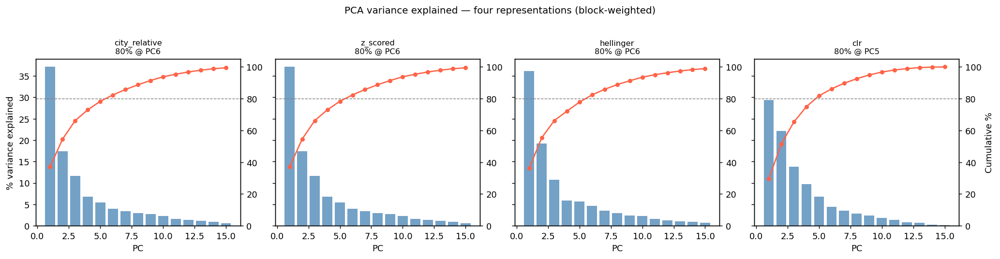

In [8]:
# PCA variance explained — compare representations
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
n_reps = len(representations)

for i, (name, X) in enumerate(representations.items()):
    ax = axes[i]
    pca = PCA(n_components=min(15, X.shape[1]))
    pca.fit(X)
    evr   = pca.explained_variance_ratio_
    cumev = np.cumsum(evr)
    n80   = int(np.searchsorted(cumev, 0.80)) + 1

    ax.bar(range(1, len(evr)+1), evr * 100, color="steelblue", alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(range(1, len(cumev)+1), cumev * 100, "o-", color="tomato", ms=4, lw=1.5)
    ax2.axhline(80, color="gray", ls="--", lw=0.8)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Cumulative %" if i == n_reps - 1 else "")
    ax.set_title(f"{name}\n80% @ PC{n80}", fontsize=9)
    ax.set_xlabel("PC")
    ax.set_ylabel("% variance explained" if i == 0 else "")

fig.suptitle("PCA variance explained — four representations (block-weighted)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** After block weighting, CLR concentrates variance most aggressively (fewest components
needed for 80%); Hellinger is similar. City-relative deviations and z-scored land between them.

For the main analysis we use **city-relative deviations** because:
- Results are directly readable as pp over/under-performance vs the city
- The SF Chronicle used the same framing
- PCA handles any residual collinearity from the simplex constraint

Note: after block weighting applies `StandardScaler` within each block, city-relative and raw
shares become mathematically equivalent for clustering — the constant shift (citywide mean) is
absorbed by standardisation. The distinction matters for interpretability in the profile plots
(§8), where we always report raw pp deviations from citywide.

## 3. Dimensionality Reduction

**PCA** is the primary reduction step for clustering. It is deterministic, globally
distance-preserving, and produces a compact representation with interpretable loadings.
We retain enough components to explain ≥90% of variance.

**UMAP** is computed here as a **visualisation layer only**. It provides an intuitive 2-D
picture of cluster separation but is not used for clustering — UMAP embeddings are not globally
distance-preserving and K-means in 2-D UMAP space can fragment or merge clusters in misleading ways.

In [9]:
# PCA: retain components for ≥90% variance in the block-weighted city-relative space
pca_full = PCA(n_components=min(15, len(ALL_COLS)))
pca_full.fit(X_rel_w)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f"PCA: {n90} components explain ≥90% of variance (block-weighted city-relative)")

pca = PCA(n_components=n90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_rel_w)
print(f"PCA output shape: {X_pca.shape}")

PCA: 9 components explain ≥90% of variance (block-weighted city-relative)
PCA output shape: (585, 9)


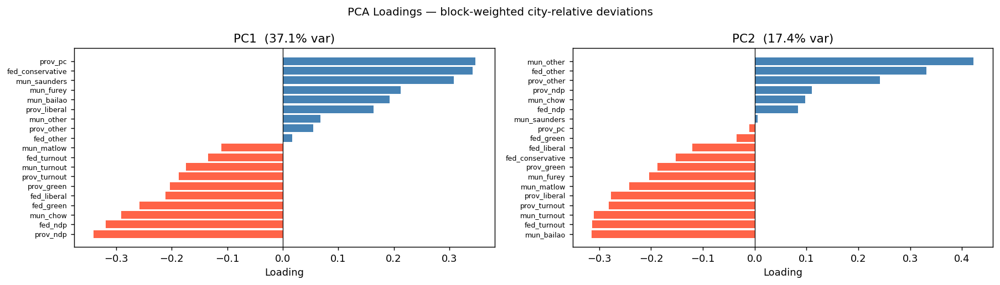

In [10]:
# PCA loading plot — top 2 PCs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for pc_idx, ax in enumerate(axes):
    loadings = pd.Series(pca.components_[pc_idx], index=ALL_COLS).sort_values()
    colors = ["tomato" if v < 0 else "steelblue" for v in loadings]
    ax.barh(range(len(loadings)), loadings.values, color=colors)
    ax.set_yticks(range(len(loadings)))
    ax.set_yticklabels(loadings.index, fontsize=7)
    ax.axvline(0, color="black", lw=0.7)
    ax.set_title(f"PC{pc_idx+1}  ({pca.explained_variance_ratio_[pc_idx]*100:.1f}% var)")
    ax.set_xlabel("Loading")

fig.suptitle("PCA Loadings — block-weighted city-relative deviations", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

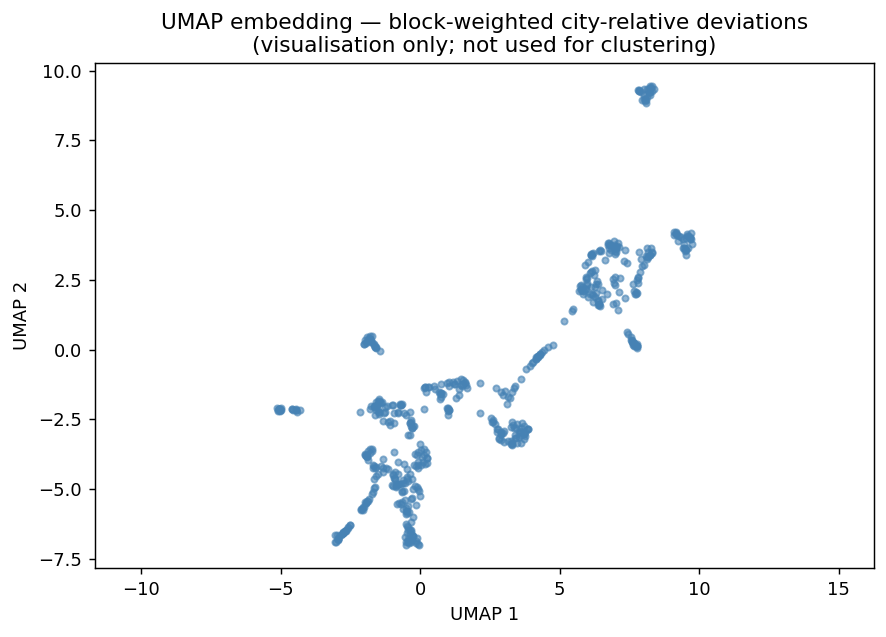

In [11]:
# UMAP: 2-D visualisation layer (not used for clustering)
# n_neighbors=20 balances local/global structure for ~585 points
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
X_umap = reducer.fit_transform(X_rel_w)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c="steelblue", s=12, alpha=0.6)
ax.set_title("UMAP embedding — block-weighted city-relative deviations\n(visualisation only; not used for clustering)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

## 4. Clustering in PCA Space

We cluster directly in PCA space (all {n90} components, ≥90% variance) rather than in UMAP 2-D.
PCA distances are globally meaningful; K-means in the full PCA space avoids the distortions
introduced by UMAP's non-linear manifold.

We compare **K-means** and **Ward hierarchical** clustering for k = 4–7 and use the silhouette
score to guide the choice of k.

Clustering (PCA space):   0%|          | 0/4 [00:00<?, ?it/s]

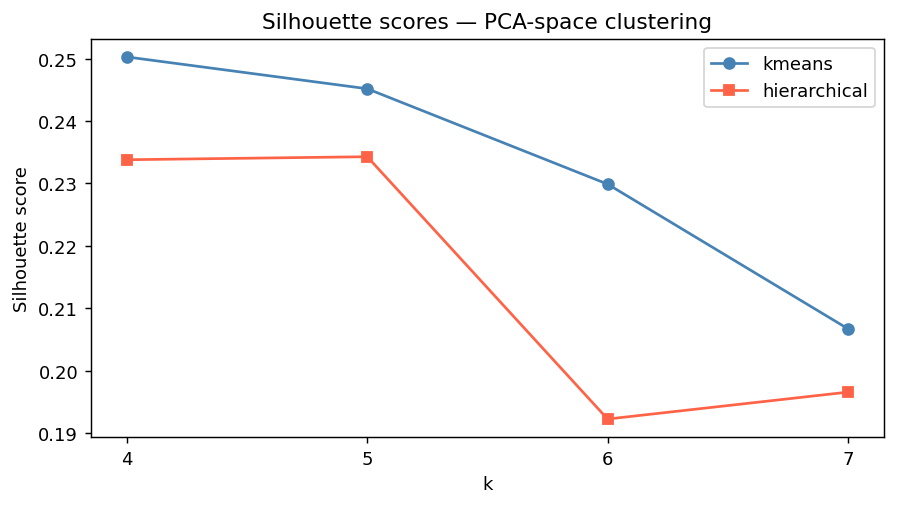

k=4: K-means=0.2503, Ward=0.2338
k=5: K-means=0.2452, Ward=0.2343
k=6: K-means=0.2299, Ward=0.1923
k=7: K-means=0.2067, Ward=0.1966


In [12]:
results_pca = {}
normal_idx = np.where(~anomaly_mask)[0]
X_pca_normal = X_pca[normal_idx]

def _assign_all(km, X_full, normal_idx, anomaly_mask):
    """Full label array: K-means labels for normal CTs, nearest centroid for anomalies."""
    labels = np.empty(len(X_full), dtype=int)
    labels[normal_idx] = km.labels_
    for i in np.where(anomaly_mask)[0]:
        labels[i] = np.argmin(np.linalg.norm(km.cluster_centers_ - X_full[i], axis=1))
    return labels

for k in tqdm(N_CLUSTERS_RANGE, desc="Clustering (PCA space)"):
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_pca_normal)
    km_labels = _assign_all(km, X_pca, normal_idx, anomaly_mask)
    km_sil    = silhouette_score(X_pca_normal, km.labels_)  # score on normal CTs only

    Z = linkage(X_pca_normal, method="ward")
    hier_normal = fcluster(Z, t=k, criterion="maxclust") - 1
    hier_sil    = silhouette_score(X_pca_normal, hier_normal)
    # Expand hier labels to all CTs (anomalies nearest to centroid of each hier cluster)
    hier_cents  = np.array([X_pca_normal[hier_normal == c].mean(axis=0)
                             for c in range(k)])
    hier_labels = np.empty(len(X_pca), dtype=int)
    hier_labels[normal_idx] = hier_normal
    for i in np.where(anomaly_mask)[0]:
        hier_labels[i] = np.argmin(np.linalg.norm(hier_cents - X_pca[i], axis=1))

    results_pca[k] = {
        "kmeans":       (km_labels, km_sil),
        "hierarchical": (hier_labels, hier_sil),
    }

fig, ax = plt.subplots(figsize=(7, 4))
for method, marker, color in [("kmeans", "o", "steelblue"), ("hierarchical", "s", "tomato")]:
    sils = [results_pca[k][method][1] for k in N_CLUSTERS_RANGE]
    ax.plot(N_CLUSTERS_RANGE, sils, marker=marker, color=color, label=method, ms=6)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_xticks(N_CLUSTERS_RANGE)
ax.set_title("Silhouette scores — PCA-space clustering")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

for k in N_CLUSTERS_RANGE:
    km_sil   = results_pca[k]["kmeans"][1]
    hier_sil = results_pca[k]["hierarchical"][1]
    print(f"k={k}: K-means={km_sil:.4f}, Ward={hier_sil:.4f}")

In [13]:
# ── Apply K_CHOSEN ────────────────────────────────────────────────────────────
# Update K_CHOSEN in the constants cell above, then re-run from here.

km_labels   = results_pca[K_CHOSEN]["kmeans"][0]
hier_labels = results_pca[K_CHOSEN]["hierarchical"][0]

# Reorder cluster IDs by geographic centroid longitude (west → east) for stable labelling
centroid_x = np.array([
    raw_gdf.geometry.centroid.x.values[km_labels == c].mean()
    for c in range(K_CHOSEN)
])
order = np.argsort(centroid_x)
remap = {old: new for new, old in enumerate(order)}
km_labels_sorted   = np.array([remap[l] for l in km_labels])
hier_labels_sorted = hier_labels   # leave hierarchical as-is for comparison

raw_gdf["cluster"]      = km_labels_sorted
raw_gdf["cluster_hier"] = hier_labels_sorted
rel_gdf["cluster"]      = km_labels_sorted

raw_gdf.to_file(PROFILES_DIR / "clustered_tracts.gpkg", driver="GPKG", layer="clustered")
print(f"Saved clustered_tracts.gpkg  (k={K_CHOSEN} K-means clusters)")

sizes = pd.Series(km_labels_sorted).value_counts().sort_index()
print("\nCluster sizes (K-means, PCA space):")
print(sizes.to_string())

Saved clustered_tracts.gpkg  (k=5 K-means clusters)

Cluster sizes (K-means, PCA space):
0    159
1    130
2    134
3     53
4    109


In [14]:
# K-means vs Ward hierarchical agreement
ari = adjusted_rand_score(km_labels_sorted, hier_labels_sorted)
print(f"Adjusted Rand Index (K-means vs Ward, k={K_CHOSEN}): {ari:.3f}")
print("  (1.0 = identical, 0 = random)")

pd.crosstab(
    pd.Series(km_labels_sorted, name="K-means"),
    pd.Series(hier_labels_sorted, name="Hierarchical"),
)

Adjusted Rand Index (K-means vs Ward, k=5): 0.632
  (1.0 = identical, 0 = random)


Hierarchical,0,1,2,3,4
K-means,,,,,
0,0,3,2,136,18
1,1,97,2,30,0
2,133,0,0,0,1
3,16,0,0,1,36
4,12,2,81,13,1


## 5. Sensitivity Analysis

Each variant changes exactly one dimension from the base configuration
(city-relative deviations, block-weighted, PCA clustering, k=5, all features).
For variants with the same k, we report the Adjusted Rand Index (ARI) against the base
to quantify how much the assignments change.

| Variant | What changes |
|---|---|
| No turnout | Drop the 3 turnout columns |
| No 'other' bucket | Drop mun_other, prov_other, fed_other |
| Hellinger transform | √(share) instead of city-relative deviations |
| CLR transform | Centred log-ratio; statistically correct for the simplex |
| k = 4 | One fewer cluster |
| k = 6 | One more cluster |
| UMAP clustering | K-means in UMAP 2-D instead of PCA (previous approach) |

**Note on raw shares vs city-relative:** After block weighting applies `StandardScaler`
within each block, the centring step absorbs the citywide mean, making raw shares and
city-relative representations mathematically identical for clustering. The distinction
is only meaningful for profile plots (§8).

In [15]:
def cluster_in_pca(X, col_names, blocks, k, var_threshold=0.90):
    """Block-weight → PCA → K-means (excluding anomalous CTs from fitting).
    Returns (full_labels, silhouette_on_normal_CTs)."""
    X_w = apply_block_weights(X, col_names, blocks)
    pf  = PCA(n_components=min(15, X_w.shape[1])); pf.fit(X_w)
    n_c = min(int(np.searchsorted(np.cumsum(pf.explained_variance_ratio_), var_threshold)) + 1,
              X_w.shape[1])
    X_emb    = PCA(n_components=n_c, random_state=RANDOM_STATE).fit_transform(X_w)
    norm_idx = np.where(~anomaly_mask)[0]
    km       = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_emb[norm_idx])
    labels_all = _assign_all(km, X_emb, norm_idx, anomaly_mask)
    return labels_all, silhouette_score(X_emb[norm_idx], km.labels_)

# ── Blocks for feature-exclusion variants ────────────────────────────────────
NO_TURN_COLS  = [c for c in ALL_COLS if "turnout" not in c]
BLOCKS_NO_TURN = {
    "municipal":  [c for c in ELECTION_BLOCKS["municipal"]  if "turnout" not in c],
    "provincial": [c for c in ELECTION_BLOCKS["provincial"] if "turnout" not in c],
    "federal":    [c for c in ELECTION_BLOCKS["federal"]    if "turnout" not in c],
}
NO_OTHER_COLS  = [c for c in ALL_COLS if "other" not in c]
BLOCKS_NO_OTHER = {
    "municipal":  [c for c in ELECTION_BLOCKS["municipal"]  if "other" not in c],
    "provincial": [c for c in ELECTION_BLOCKS["provincial"] if "other" not in c],
    "federal":    [c for c in ELECTION_BLOCKS["federal"]    if "other" not in c],
}

X_rel_no_turn  = X_rel[:, [ALL_COLS.index(c) for c in NO_TURN_COLS]]
X_rel_no_other = X_rel[:, [ALL_COLS.index(c) for c in NO_OTHER_COLS]]

# UMAP clustering: K-means in the already-computed X_umap (same block-weighted input)
_norm = np.where(~anomaly_mask)[0]
km_umap = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_umap.fit(X_umap[_norm])
umap_labels = _assign_all(km_umap, X_umap, _norm, anomaly_mask)
umap_sil    = silhouette_score(X_umap[_norm], km_umap.labels_)
umap_ari    = adjusted_rand_score(km_labels_sorted, umap_labels)

# ── Run all variants ──────────────────────────────────────────────────────────
sensitivity_variants = [
    ("Base (city-relative, k=5, PCA)",  X_rel,          ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("No turnout",                       X_rel_no_turn,  NO_TURN_COLS,   BLOCKS_NO_TURN,  K_CHOSEN),
    ("No 'other' bucket",                X_rel_no_other, NO_OTHER_COLS,  BLOCKS_NO_OTHER, K_CHOSEN),
    ("Hellinger transform",              X_hell,         ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("CLR transform",                    X_clr,          ALL_COLS,       ELECTION_BLOCKS, K_CHOSEN),
    ("k = 4",                            X_rel,          ALL_COLS,       ELECTION_BLOCKS, 4),
    ("k = 6",                            X_rel,          ALL_COLS,       ELECTION_BLOCKS, 6),
]

rows = []
print(f"{'Variant':<38} {'k':>2}  {'Silhouette':>10}  {'ARI vs base':>11}")
print("-" * 68)
for name, X, cols, blocks, k in sensitivity_variants:
    labels, sil = cluster_in_pca(X, cols, blocks, k)
    ari = adjusted_rand_score(km_labels_sorted, labels) if k == K_CHOSEN else float("nan")
    ari_str = f"{ari:.3f}" if not np.isnan(ari) else "—"
    print(f"{name:<38} {k:>2}  {sil:>10.4f}  {ari_str:>11}")
    rows.append({"Variant": name, "k": k, "Silhouette": round(sil, 4),
                 "ARI vs base": ari_str})

# UMAP clustering row
print(f"{'UMAP clustering':<38} {K_CHOSEN:>2}  {umap_sil:>10.4f}  {umap_ari:>11.3f}")
rows.append({"Variant": "UMAP clustering", "k": K_CHOSEN,
             "Silhouette": round(umap_sil, 4), "ARI vs base": f"{umap_ari:.3f}"})

sensitivity_df = pd.DataFrame(rows)
sensitivity_df.to_csv(EXPLORE_DIR / "sensitivity_summary.csv", index=False)
print("\nSaved sensitivity_summary.csv to explore/")

Variant                                 k  Silhouette  ARI vs base
--------------------------------------------------------------------


Base (city-relative, k=5, PCA)          5      0.2452        1.000


No turnout                              5      0.2932        0.690


No 'other' bucket                       5      0.2348        0.878


Hellinger transform                     5      0.2453        0.727


CLR transform                           5      0.3646        0.327


k = 4                                   4      0.2503            —


k = 6                                   6      0.2299            —
UMAP clustering                         5      0.5561        0.430

Saved sensitivity_summary.csv to explore/


## 6. Riding-Level Analysis

Provincial and federal elections are contested at the riding level. Two census tracts with
identical underlying political preferences could vote very differently because of candidate
quality, incumbent effects, and strategic voting dynamics within their riding.

To test how much of the cluster structure is driven by riding-level effects vs genuine
neighbourhood character, we compute **within-riding residuals**: for each feature, we subtract
the mean of all tracts in the same riding, leaving only the variation *within* a riding.
We then cluster these residuals using the same PCA pipeline.

**Riding assignment:**
- **Municipal features** → Toronto wards (derived from 2023 polling subdivision boundaries)
  — used as the sub-city unit for a city-wide mayoral race; no within-race riding effect,
  but wards capture local political organisation
- **Provincial features** → Ontario 2025 provincial electoral ridings (25 Toronto ridings)
- **Federal features** → Canada 2025 federal electoral ridings (24 Toronto ridings)

If the riding-residual clusters resemble the main clusters (high ARI), riding effects are
**not** the primary driver. If ARI is near zero, the main clusters are largely a
riding-level phenomenon.

In [16]:
# ── Load geographic boundaries ────────────────────────────────────────────────
# Ward polygons: dissolve 2023 polling subdivisions on the first 2 digits of AREA_LONG_CODE
subdiv_gdf = gpd.read_file(RIDING_DIR / "toronto_2023_subdivisions.geojson")
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf   = subdiv_gdf.dissolve(by="ward")

prov_ridings = gpd.read_file(RIDING_DIR / "ont_2025_ridings.geojson")
fed_ridings  = gpd.read_file(RIDING_DIR / "fed_2025_ridings.geojson")

print(f"Ward polygons: {len(ward_gdf)}")
print(f"Provincial ridings (full file): {len(prov_ridings)}")
print(f"Federal ridings (full file):    {len(fed_ridings)}")

# ── Assign each CT to its riding via centroid spatial join ───────────────────
def assign_ridings(ct_gdf, ward_gdf, prov_ridings, fed_ridings):
    """Return a DataFrame with columns [ct_id, mun_riding, prov_riding, fed_riding].
    Falls back to nearest polygon for any centroid that misses its riding."""
    centroids_gdf = gpd.GeoDataFrame(
        {"ct_id": ct_gdf["ct_id"].values},
        geometry=ct_gdf.geometry.centroid.values,
        crs=ct_gdf.crs,
    )
    bbox = shapely_box(*ct_gdf.total_bounds)
    prov_local = prov_ridings[prov_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    fed_local  = fed_ridings[fed_ridings.geometry.intersects(bbox)][["RIDINGNAME",  "geometry"]].reset_index(drop=True)
    ward_local = ward_gdf.reset_index()[["ward", "geometry"]].copy()

    def sjoin_with_fallback(pts, polys, id_col, out_col):
        joined = gpd.sjoin(pts, polys[[id_col, "geometry"]], how="left", predicate="within")
        joined = joined.drop_duplicates("ct_id")[["ct_id", id_col]]
        missing_mask = joined[id_col].isna()
        if missing_mask.any():
            for _, row in joined[missing_mask].iterrows():
                pt = pts.loc[pts["ct_id"] == row["ct_id"], "geometry"].values[0]
                nearest = polys.geometry.distance(pt).idxmin()
                joined.loc[joined["ct_id"] == row["ct_id"], id_col] = polys.loc[nearest, id_col]
        return joined.rename(columns={id_col: out_col})

    ward_j = sjoin_with_fallback(centroids_gdf, ward_local, "ward",      "mun_riding")
    prov_j = sjoin_with_fallback(centroids_gdf, prov_local, "RIDINGNAME","prov_riding")
    fed_j  = sjoin_with_fallback(centroids_gdf, fed_local,  "RIDINGNAME","fed_riding")

    return ward_j.merge(prov_j, on="ct_id").merge(fed_j, on="ct_id")

riding_df = assign_ridings(raw_gdf, ward_gdf, prov_ridings, fed_ridings)
print(f"\nCTs assigned: {len(riding_df)}")
print(f"  Wards: {riding_df['mun_riding'].nunique()} | "
      f"Prov ridings: {riding_df['prov_riding'].nunique()} | "
      f"Fed ridings: {riding_df['fed_riding'].nunique()}")
print(f"  Missing: mun={riding_df['mun_riding'].isna().sum()}, "
      f"prov={riding_df['prov_riding'].isna().sum()}, "
      f"fed={riding_df['fed_riding'].isna().sum()}")

Ward polygons: 25
Provincial ridings (full file): 124
Federal ridings (full file):    343

CTs assigned: 585
  Wards: 25 | Prov ridings: 25 | Fed ridings: 24
  Missing: mun=0, prov=0, fed=0


In [17]:
# ── Compute within-riding residuals ──────────────────────────────────────────
MUN_COLS  = ["mun_turnout"]  + MUN_SHARE_COLS
PROV_COLS = ["prov_turnout"] + PROV_SHARE_COLS
FED_COLS  = ["fed_turnout"]  + FED_SHARE_COLS

def compute_riding_residuals(raw_gdf, riding_df, mun_cols, prov_cols, fed_cols):
    """Subtract the within-riding mean from each CT's features.
    Each election level uses its own geographic unit."""
    df = raw_gdf[mun_cols + prov_cols + fed_cols].copy()
    df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))

    mun_means  = df.groupby("mun_riding")[mun_cols].transform("mean")
    prov_means = df.groupby("prov_riding")[prov_cols].transform("mean")
    fed_means  = df.groupby("fed_riding")[fed_cols].transform("mean")

    res = pd.DataFrame(index=df.index)
    res[mun_cols]  = df[mun_cols].values  - mun_means.values
    res[prov_cols] = df[prov_cols].values - prov_means.values
    res[fed_cols]  = df[fed_cols].values  - fed_means.values
    return res

resid_df = compute_riding_residuals(raw_gdf, riding_df, MUN_COLS, PROV_COLS, FED_COLS)

# Sanity check: column means should be ~0
print("Within-riding residual column means (should be ~0):")
print(resid_df.mean().round(8).to_string())

Within-riding residual column means (should be ~0):
mun_turnout        -0.0
mun_chow            0.0
mun_bailao         -0.0
mun_saunders        0.0
mun_furey          -0.0
mun_matlow          0.0
mun_other          -0.0
prov_turnout       -0.0
prov_pc             0.0
prov_ndp           -0.0
prov_liberal       -0.0
prov_green          0.0
prov_other         -0.0
fed_turnout         0.0
fed_liberal         0.0
fed_conservative    0.0
fed_ndp             0.0
fed_green          -0.0
fed_other          -0.0


In [18]:
# ── Cluster the within-riding residuals ──────────────────────────────────────
X_resid = resid_df[ALL_COLS].values.astype(float)
X_resid_w = apply_block_weights(X_resid, ALL_COLS, ELECTION_BLOCKS)

pca_resid_full = PCA(n_components=min(15, X_resid_w.shape[1]))
pca_resid_full.fit(X_resid_w)
n90_resid = int(np.searchsorted(np.cumsum(pca_resid_full.explained_variance_ratio_), 0.90)) + 1
X_pca_resid = PCA(n_components=n90_resid, random_state=RANDOM_STATE).fit_transform(X_resid_w)

_norm_r  = np.where(~anomaly_mask)[0]
km_resid = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_resid.fit(X_pca_resid[_norm_r])
resid_labels = _assign_all(km_resid, X_pca_resid, _norm_r, anomaly_mask)
resid_sil    = silhouette_score(X_pca_resid[_norm_r], km_resid.labels_)
resid_ari    = adjusted_rand_score(km_labels_sorted, resid_labels)

print(f"Within-riding residual clustering (k={K_CHOSEN}):")
print(f"  Silhouette score: {resid_sil:.4f}  (main: {results_pca[K_CHOSEN]['kmeans'][1]:.4f})")
print(f"  ARI vs main clusters: {resid_ari:.4f}")
print()
print("ARI interpretation:")
print("  Near 1.0 → riding effects are NOT the primary driver; neighbourhood character dominates")
print("  Near 0.0 → main clusters are largely a riding-level phenomenon")
print()

# Save residual cluster assignments for mapping
raw_gdf["cluster_resid"] = resid_labels
raw_gdf.to_file(EXPLORE_DIR / "clustered_tracts_riding_residual.gpkg", driver="GPKG", layer="residual")
print("Saved clustered_tracts_riding_residual.gpkg to explore/")

Within-riding residual clustering (k=5):
  Silhouette score: 0.1364  (main: 0.2452)
  ARI vs main clusters: 0.0868

ARI interpretation:
  Near 1.0 → riding effects are NOT the primary driver; neighbourhood character dominates
  Near 0.0 → main clusters are largely a riding-level phenomenon

Saved clustered_tracts_riding_residual.gpkg to explore/


## 7. Visualisations

Three views of the clustering:
1. **Geographic map** — where each political group lives in the city
2. **UMAP scatter** — how separated the groups are in political space (clusters coloured by the PCA K-means labels)
3. **Riding-residual comparison** — main clusters vs within-riding-residual clusters side by side

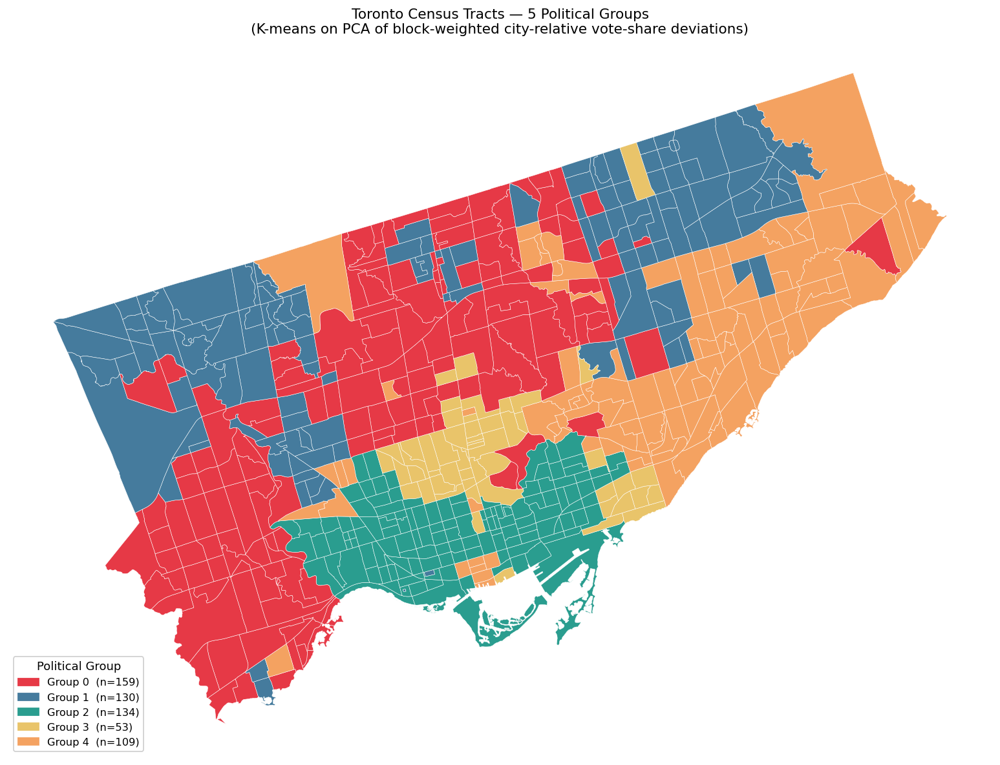

In [19]:
cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])

fig, ax = plt.subplots(figsize=(12, 13))
raw_gdf.plot(
    column="cluster", ax=ax, categorical=True,
    cmap=cmap, edgecolor="white", linewidth=0.3, legend=False,
)
patches = [
    mpatches.Patch(color=PALETTE[c], label=f"Group {c}  (n={sizes[c]})")
    for c in range(K_CHOSEN)
]
ax.legend(handles=patches, loc="lower left", title="Political Group",
          framealpha=0.9, fontsize=9)
ax.set_title(
    f"Toronto Census Tracts — {K_CHOSEN} Political Groups\n"
    "(K-means on PCA of block-weighted city-relative vote-share deviations)",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_map.png", dpi=200, bbox_inches="tight")
plt.show()

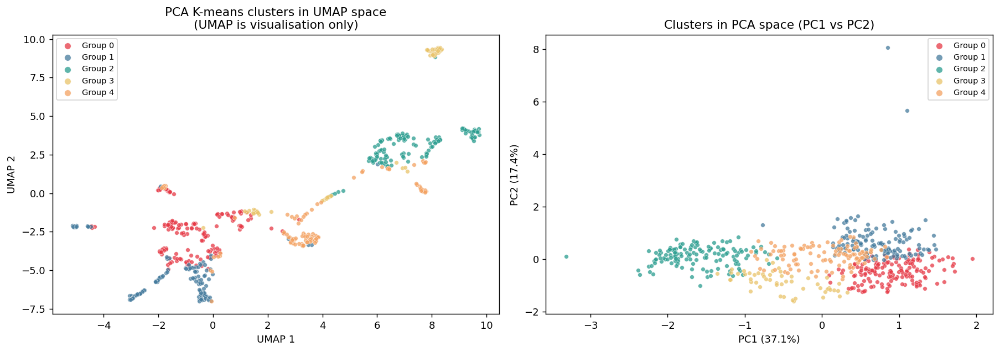

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PCA-derived clusters in UMAP space
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    ax1.scatter(X_umap[mask, 0], X_umap[mask, 1],
                color=PALETTE[c], label=f"Group {c}",
                s=18, alpha=0.75, edgecolors="white", linewidths=0.3)
ax1.set_title("PCA K-means clusters in UMAP space\n(UMAP is visualisation only)")
ax1.set_xlabel("UMAP 1"); ax1.set_ylabel("UMAP 2")
ax1.legend(markerscale=1.5, fontsize=8)

# PCA scatter (PC1 vs PC2)
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=PALETTE[c], label=f"Group {c}",
                s=18, alpha=0.75, edgecolors="white", linewidths=0.3)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("Clusters in PCA space (PC1 vs PC2)")
ax2.legend(markerscale=1.5, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "umap_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

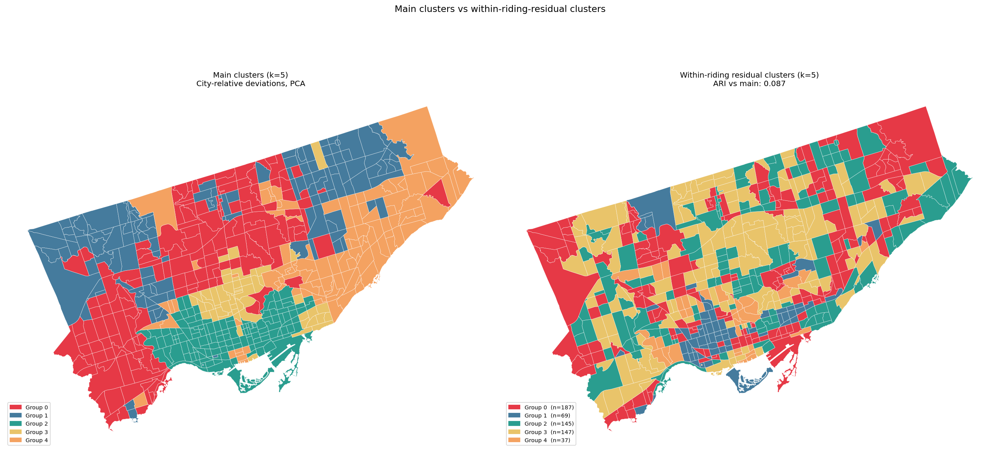

In [21]:
# Riding-residual comparison map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN})\nCity-relative deviations, PCA", fontsize=11)
ax1.axis("off")
patches = [mpatches.Patch(color=PALETTE[c], label=f"Group {c}") for c in range(K_CHOSEN)]
ax1.legend(handles=patches, loc="lower left", fontsize=8)

cmap_resid = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster_resid", ax=ax2, categorical=True,
             cmap=cmap_resid, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Within-riding residual clusters (k={K_CHOSEN})\nARI vs main: {resid_ari:.3f}", fontsize=11)
ax2.axis("off")
resid_sizes = pd.Series(resid_labels).value_counts().sort_index()
patches2 = [mpatches.Patch(color=PALETTE[c], label=f"Group {c}  (n={resid_sizes.get(c, 0)})") for c in range(K_CHOSEN)]
ax2.legend(handles=patches2, loc="lower left", fontsize=8)

fig.suptitle("Main clusters vs within-riding-residual clusters", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "cluster_map_riding_residual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Cluster Profiles

The heatmap shows each cluster's average **deviation from citywide** for every
party/candidate and turnout. Green = above city average; red = below.
Values are in percentage points.

These are computed from the *raw* city-relative deviations (not the block-weighted
PCA input), so they are directly interpretable.

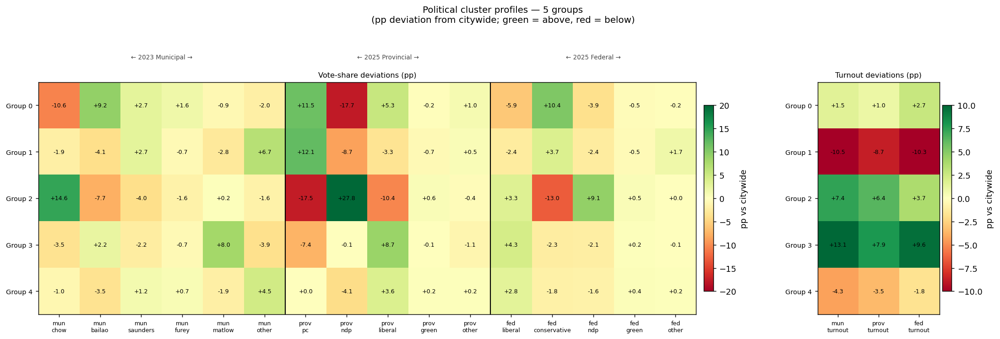

In [22]:
# Cluster-average pp deviations (raw city-relative, not block-weighted)
profile_rows = []
for c in range(K_CHOSEN):
    mask = km_labels_sorted == c
    row  = rel_df[ALL_COLS].values[mask].mean(axis=0)
    profile_rows.append(row)

profiles = pd.DataFrame(
    np.array(profile_rows) * 100,
    columns=ALL_COLS,
    index=[f"Group {c}" for c in range(K_CHOSEN)],
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, (ax_shares, ax_turn) = plt.subplots(
    1, 2,
    figsize=(17, 3.5 + K_CHOSEN * 0.4),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]},
)

def draw_heatmap(ax, data, cols, title, vabs=20):
    im = ax.imshow(data[cols].values, cmap="RdYlGn",
                   aspect="auto", vmin=-vabs, vmax=vabs)
    for i in range(data.shape[0]):
        for j, col in enumerate(cols):
            val = data[col].iloc[i]
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                    fontsize=7, color="black")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=7, rotation=0)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=9)
    return im

im1 = draw_heatmap(ax_shares, profiles, SHARE_COLS, "Vote-share deviations (pp)")
im2 = draw_heatmap(ax_turn,   profiles, TURNOUT_COLS, "Turnout deviations (pp)", vabs=10)

fig.colorbar(im1, ax=ax_shares, label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=ax_turn,   label="pp vs citywide", shrink=0.8, pad=0.02)

n_mun = len(MUN_SHARE_COLS); n_prov = len(PROV_SHARE_COLS)
for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
    ax_shares.axvline(x, color="black", lw=1.2)
for x, label in [
    (n_mun / 2 - 0.5,                              "← 2023 Municipal →"),
    (n_mun + n_prov / 2 - 0.5,                     "← 2025 Provincial →"),
    (n_mun + n_prov + len(FED_SHARE_COLS)/2 - 0.5, "← 2025 Federal →"),
]:
    ax_shares.text(x, -1.1, label, ha="center", va="top", fontsize=7.5, color="#444")

fig.suptitle(f"Political cluster profiles — {K_CHOSEN} groups\n"
             "(pp deviation from citywide; green = above, red = below)",
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_profiles_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
# Summary table
print(f"=== Cluster Summary (k={K_CHOSEN}) ===\n")
for c in range(K_CHOSEN):
    mask   = km_labels_sorted == c
    row    = profiles.loc[f"Group {c}", SHARE_COLS]
    t_dev  = profiles.loc[f"Group {c}", TURNOUT_COLS]
    top3_over  = row.nlargest(3)
    top3_under = row.nsmallest(3)
    print(f"Group {c}  ({mask.sum()} tracts)")
    print(f"  Turnout: " + ", ".join(f"{col.replace('_turnout','')}={v:+.1f}pp" for col, v in t_dev.items()))
    print(f"  Over:    " + ", ".join(f"{col}={v:+.1f}pp" for col, v in top3_over.items()))
    print(f"  Under:   " + ", ".join(f"{col}={v:+.1f}pp" for col, v in top3_under.items()))
    print()

=== Cluster Summary (k=5) ===

Group 0  (159 tracts)
  Turnout: mun=+1.5pp, prov=+1.0pp, fed=+2.7pp
  Over:    prov_pc=+11.5pp, fed_conservative=+10.4pp, mun_bailao=+9.2pp
  Under:   prov_ndp=-17.7pp, mun_chow=-10.6pp, fed_liberal=-5.9pp

Group 1  (130 tracts)
  Turnout: mun=-10.5pp, prov=-8.7pp, fed=-10.3pp
  Over:    prov_pc=+12.1pp, mun_other=+6.7pp, fed_conservative=+3.7pp
  Under:   prov_ndp=-8.7pp, mun_bailao=-4.1pp, prov_liberal=-3.3pp

Group 2  (134 tracts)
  Turnout: mun=+7.4pp, prov=+6.4pp, fed=+3.7pp
  Over:    prov_ndp=+27.8pp, mun_chow=+14.6pp, fed_ndp=+9.1pp
  Under:   prov_pc=-17.5pp, fed_conservative=-13.0pp, prov_liberal=-10.4pp

Group 3  (53 tracts)
  Turnout: mun=+13.1pp, prov=+7.9pp, fed=+9.6pp
  Over:    prov_liberal=+8.7pp, mun_matlow=+8.0pp, fed_liberal=+4.3pp
  Under:   prov_pc=-7.4pp, mun_other=-3.9pp, mun_chow=-3.5pp

Group 4  (109 tracts)
  Turnout: mun=-4.3pp, prov=-3.5pp, fed=-1.8pp
  Over:    mun_other=+4.5pp, prov_liberal=+3.6pp, fed_liberal=+2.8pp
  Unde

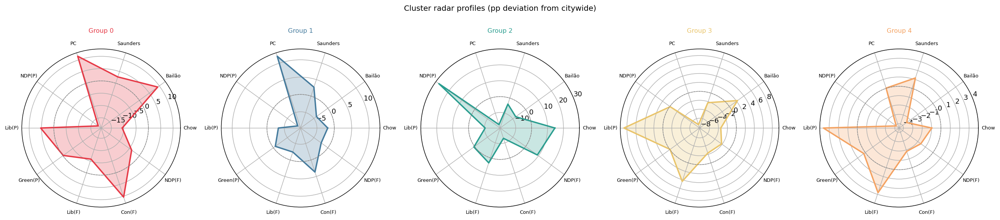

In [24]:
# Radar / spider charts
radar_cols = [
    "mun_chow", "mun_bailao", "mun_saunders",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green",
    "fed_liberal", "fed_conservative", "fed_ndp",
]
radar_labels = [
    "Chow", "Bailão", "Saunders",
    "PC", "NDP(P)", "Lib(P)", "Green(P)",
    "Lib(F)", "Con(F)", "NDP(F)",
]
N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4 * K_CHOSEN, 4.5),
                          subplot_kw={"polar": True})
if K_CHOSEN == 1: axes = [axes]

for c, ax in enumerate(axes):
    values = profiles.loc[f"Group {c}", radar_cols].values.tolist() + [profiles.loc[f"Group {c}", radar_cols].values[0]]
    ax.plot(angles, values, color=PALETTE[c], lw=2)
    ax.fill(angles, values, color=PALETTE[c], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_title(f"Group {c}", fontsize=9, pad=12, color=PALETTE[c])
    ax.axhline(0, color="gray", lw=0.7, ls="--")

fig.suptitle("Cluster radar profiles (pp deviation from citywide)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Export full profiles table to profiles/
profiles_out = profiles.copy()
profiles_out.insert(0, "n_tracts", [int((km_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
profiles_out.to_csv(PROFILES_DIR / "cluster_profiles.csv")
print("Saved cluster_profiles.csv to profiles/")
print()
print(profiles_out[["n_tracts"] + SHARE_COLS].round(1).to_string())

Saved cluster_profiles.csv to profiles/

         n_tracts  mun_chow  mun_bailao  mun_saunders  mun_furey  mun_matlow  mun_other  prov_pc  prov_ndp  prov_liberal  prov_green  prov_other  fed_liberal  fed_conservative  fed_ndp  fed_green  fed_other
Group 0       159     -10.6         9.2           2.7        1.6        -0.9       -2.0     11.5     -17.7           5.3        -0.2         1.0         -5.9              10.4     -3.9       -0.5       -0.2
Group 1       130      -1.9        -4.1           2.7       -0.7        -2.8        6.7     12.1      -8.7          -3.3        -0.7         0.5         -2.4               3.7     -2.4       -0.5        1.7
Group 2       134      14.6        -7.7          -4.0       -1.6         0.2       -1.6    -17.5      27.8         -10.4         0.6        -0.4          3.3             -13.0      9.1        0.5        0.0
Group 3        53      -3.5         2.2          -2.2       -0.7         8.0       -3.9     -7.4      -0.1           8.7        -0.

## 8B. Vote-Weighted Riding-Residual Cluster Profiles

Standard riding residuals subtract the *mean tract value* within a riding — each tract counts equally regardless of how many votes were cast there. A better benchmark is the **actual riding-level result**: party shares weighted by each tract's total valid votes, turnout weighted by registered electors.

Residual = tract share − vote-weighted riding-level share

This reflects what actually happened in the riding, not an unweighted average of small and large tracts.

In [26]:
# ── Vote-weighted riding residuals ────────────────────────────────────────────
def compute_vote_weighted_residuals(raw_gdf, riding_df,
                                    mun_gdf, prov_gdf, fed_gdf,
                                    mun_cols, prov_cols, fed_cols):
    """Subtract the vote-weighted riding result from each CT.
    Party shares weighted by estimated_valid_candidate_votes;
    turnout weighted by estimated_electors."""
    all_cols = mun_cols + prov_cols + fed_cols
    df = raw_gdf[all_cols].copy()
    df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))
    df["mun_votes"]  = mun_gdf.set_index("ct_id")["estimated_valid_candidate_votes"]
    df["mun_elecs"]  = mun_gdf.set_index("ct_id")["estimated_electors"]
    df["prov_votes"] = prov_gdf.set_index("ct_id")["estimated_valid_candidate_votes"]
    df["prov_elecs"] = prov_gdf.set_index("ct_id")["estimated_electors"]
    df["fed_votes"]  = fed_gdf.set_index("ct_id")["estimated_valid_candidate_votes"]
    df["fed_elecs"]  = fed_gdf.set_index("ct_id")["estimated_electors"]

    def wtd_mean(value_cols, weight_col, group_col):
        w = df[weight_col].fillna(1.0)
        out = {}
        for col in value_cols:
            wv = (df[col] * w).groupby(df[group_col]).transform("sum")
            ws = w.groupby(df[group_col]).transform("sum")
            out[col] = (wv / ws).values
        return pd.DataFrame(out, index=df.index)

    mun_s  = [c for c in mun_cols  if "turnout" not in c]
    mun_t  = [c for c in mun_cols  if "turnout" in c]
    prov_s = [c for c in prov_cols if "turnout" not in c]
    prov_t = [c for c in prov_cols if "turnout" in c]
    fed_s  = [c for c in fed_cols  if "turnout" not in c]
    fed_t  = [c for c in fed_cols  if "turnout" in c]

    riding_avg = pd.concat([
        wtd_mean(mun_s,  "mun_votes",  "mun_riding"),
        wtd_mean(mun_t,  "mun_elecs",  "mun_riding"),
        wtd_mean(prov_s, "prov_votes", "prov_riding"),
        wtd_mean(prov_t, "prov_elecs", "prov_riding"),
        wtd_mean(fed_s,  "fed_votes",  "fed_riding"),
        wtd_mean(fed_t,  "fed_elecs",  "fed_riding"),
    ], axis=1)[all_cols]

    res = pd.DataFrame(
        df[all_cols].values - riding_avg.values,
        columns=all_cols, index=df.index,
    )
    return res, riding_avg


vw_resid_df, vw_riding_avg = compute_vote_weighted_residuals(
    raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, MUN_COLS, PROV_COLS, FED_COLS
)

vw_labels, vw_sil = cluster_in_pca(
    vw_resid_df[ALL_COLS].values.astype(float), ALL_COLS, ELECTION_BLOCKS, K_CHOSEN
)
vw_ari = adjusted_rand_score(km_labels_sorted, vw_labels)

vw_cx = np.array([raw_gdf.geometry.centroid.x.values[vw_labels == c].mean() for c in range(K_CHOSEN)])
vw_remap = {old: new for new, old in enumerate(np.argsort(vw_cx))}
vw_labels_sorted = np.array([vw_remap[l] for l in vw_labels])
raw_gdf["cluster_vw_resid"] = vw_labels_sorted
vw_sizes = pd.Series(vw_labels_sorted).value_counts().sort_index()

print(f"Vote-weighted residual clustering (k={K_CHOSEN}):")
print(f"  Silhouette: {vw_sil:.4f}   ARI vs main: {vw_ari:.4f}")
print("Cluster sizes:", vw_sizes.to_dict())

vw_resid_profiles = pd.DataFrame(
    np.array([vw_resid_df[ALL_COLS].values[vw_labels_sorted == c].mean(axis=0)
              for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"VW {c}" for c in range(K_CHOSEN)],
)
vw_abs_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[vw_labels_sorted == c].mean(axis=0)
              for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"VW {c}" for c in range(K_CHOSEN)],
)


Vote-weighted residual clustering (k=5):
  Silhouette: 0.1382   ARI vs main: 0.0796
Cluster sizes: {0: 34, 1: 64, 2: 155, 3: 179, 4: 153}


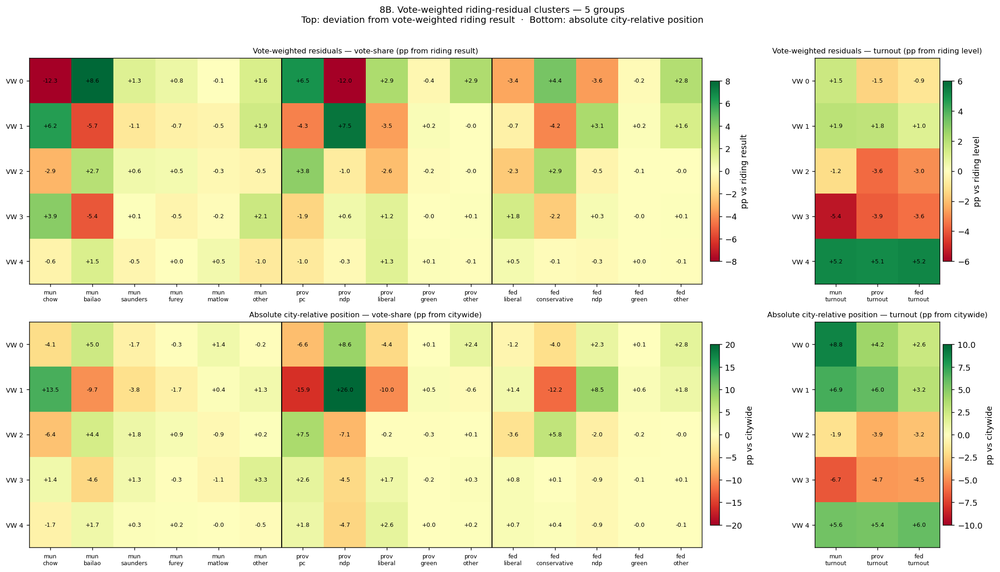

In [27]:
fig, axes = plt.subplots(
    2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]},
)
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)

im1 = draw_heatmap(axes[0, 0], vw_resid_profiles, SHARE_COLS,
                   "Vote-weighted residuals — vote-share (pp from riding result)", vabs=8)
im2 = draw_heatmap(axes[0, 1], vw_resid_profiles, TURNOUT_COLS,
                   "Vote-weighted residuals — turnout (pp from riding level)", vabs=6)
im3 = draw_heatmap(axes[1, 0], vw_abs_profiles, SHARE_COLS,
                   "Absolute city-relative position — vote-share (pp from citywide)", vabs=20)
im4 = draw_heatmap(axes[1, 1], vw_abs_profiles, TURNOUT_COLS,
                   "Absolute city-relative position — turnout (pp from citywide)", vabs=10)

for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)

fig.colorbar(im1, ax=axes[0, 0], label="pp vs riding result", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs riding level",  shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs citywide",      shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs citywide",      shrink=0.8, pad=0.02)
fig.suptitle(
    f"8B. Vote-weighted riding-residual clusters — {K_CHOSEN} groups\n"
    "Top: deviation from vote-weighted riding result  ·  Bottom: absolute city-relative position",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8b_vw_resid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


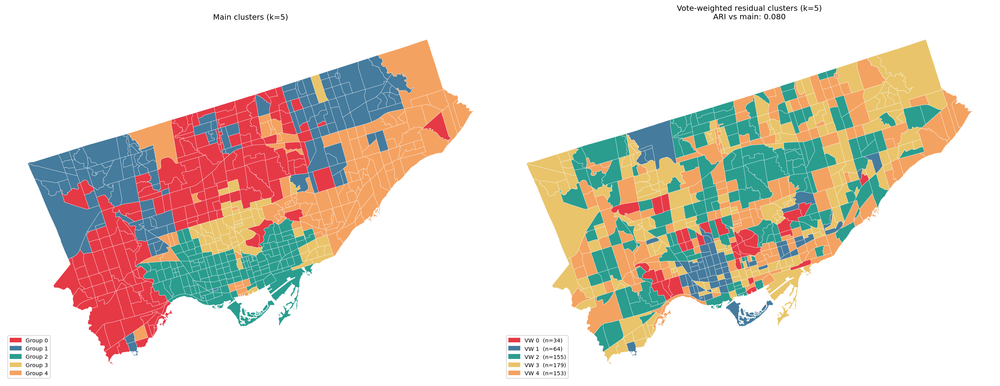

=== 8B. Vote-Weighted Riding-Residual Clusters (k=5) ===
VW Group 0  (34 tracts)
  Turnout: mun=+1.5pp, prov=-1.5pp, fed=-0.9pp
  Largest residuals: mun_chow=-12.3pp, prov_ndp=-12.0pp, mun_bailao=+8.6pp, prov_pc=+6.5pp
  City position:     prov_ndp=+8.6pp, prov_pc=-6.6pp, mun_bailao=+5.0pp

VW Group 1  (64 tracts)
  Turnout: mun=+1.9pp, prov=+1.8pp, fed=+1.0pp
  Largest residuals: prov_ndp=+7.5pp, mun_chow=+6.2pp, mun_bailao=-5.7pp, prov_pc=-4.3pp
  City position:     prov_ndp=+26.0pp, prov_pc=-15.9pp, mun_chow=+13.5pp

VW Group 2  (155 tracts)
  Turnout: mun=-1.2pp, prov=-3.6pp, fed=-3.0pp
  Largest residuals: prov_pc=+3.8pp, fed_conservative=+2.9pp, mun_chow=-2.9pp, mun_bailao=+2.7pp
  City position:     prov_pc=+7.5pp, prov_ndp=-7.1pp, mun_chow=-6.4pp

VW Group 3  (179 tracts)
  Turnout: mun=-5.4pp, prov=-3.9pp, fed=-3.6pp
  Largest residuals: mun_bailao=-5.4pp, mun_chow=+3.9pp, fed_conservative=-2.2pp, mun_other=+2.1pp
  City position:     mun_bailao=-4.6pp, prov_ndp=-4.5pp, mun_ot

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])

raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN})", fontsize=11)
ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)

raw_gdf.plot(column="cluster_vw_resid", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Vote-weighted residual clusters (k={K_CHOSEN})\nARI vs main: {vw_ari:.3f}",
              fontsize=11)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"VW {c}  (n={vw_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8b_vw_resid_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"=== 8B. Vote-Weighted Riding-Residual Clusters (k={K_CHOSEN}) ===")
for c in range(K_CHOSEN):
    mask  = vw_labels_sorted == c
    row   = vw_resid_profiles.iloc[c]
    t_res = row[TURNOUT_COLS]
    top4  = row[SHARE_COLS].abs().nlargest(4).index
    top3_abs = vw_abs_profiles.iloc[c][SHARE_COLS].abs().nlargest(3).index
    print(f"VW Group {c}  ({mask.sum()} tracts)")
    print(f"  Turnout: " + ", ".join(f"{col.replace('_turnout','')}={t_res[col]:+.1f}pp"
                                      for col in TURNOUT_COLS))
    print(f"  Largest residuals: " + ", ".join(f"{col}={row[col]:+.1f}pp" for col in top4))
    print(f"  City position:     " + ", ".join(
          f"{col}={vw_abs_profiles.iloc[c][col]:+.1f}pp" for col in top3_abs))
    print()

_out8b = vw_abs_profiles.copy()
_out8b.insert(0, "n_tracts", [int((vw_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8b.to_csv(EXPLORE_DIR / "8b_vw_resid_profiles.csv")
print("Saved: 8b_vw_resid_heatmap.png, 8b_vw_resid_map.png, 8b_vw_resid_profiles.csv")


## 8C. Spatial-Neighbour Residual Clusters

Instead of asking 'is this tract unusual for its riding?', we ask: **'is this tract unusual compared with its immediate neighbours in space?'**

For each census tract we subtract the mean of its 10 nearest neighbours by centroid distance. This is purely geography-driven — no electoral boundary is assumed. It captures local political clustering and discontinuities independent of riding structure.

8C. Spatial-neighbour residuals (k=10 nearest, 5 clusters):
  Silhouette: 0.0953   ARI vs main: 0.0512
Cluster sizes: {0: 69, 1: 59, 2: 132, 3: 174, 4: 151}


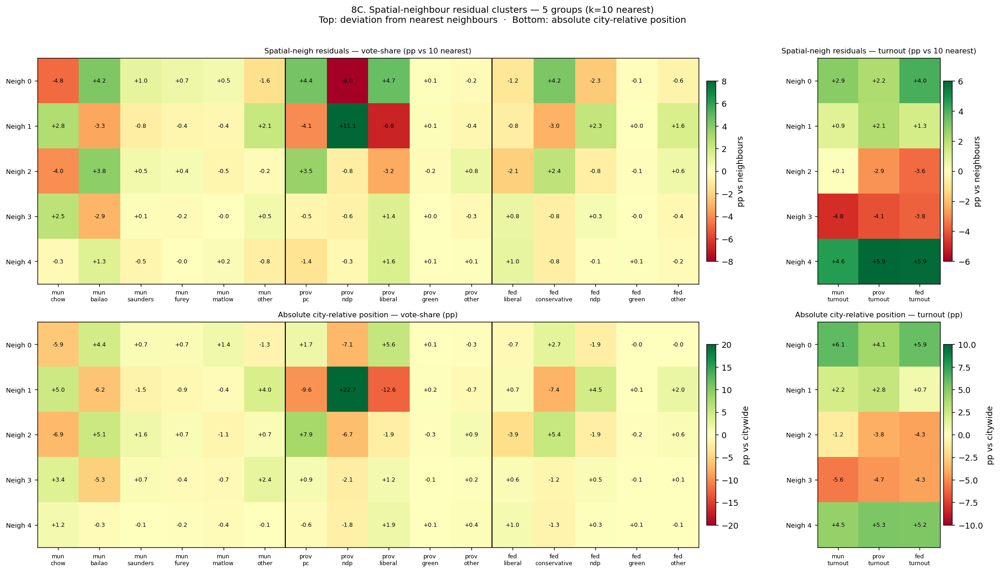

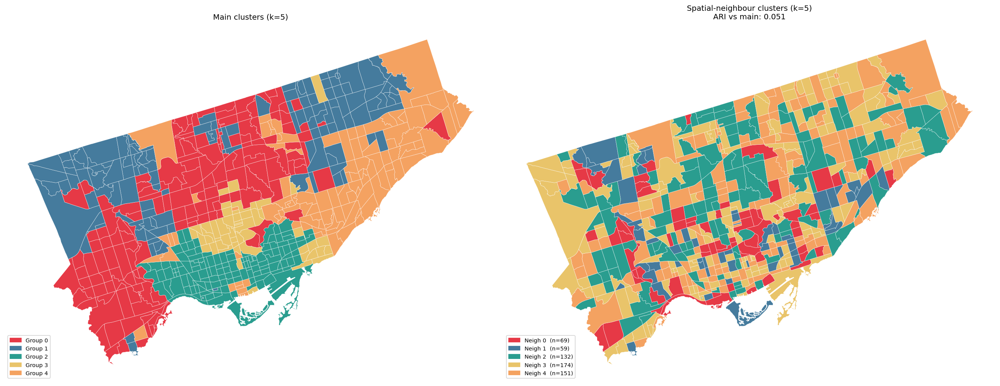

Neigh Group 0  (69 tracts)  Largest residuals: prov_ndp=-9.0pp, mun_chow=-4.8pp, prov_liberal=+4.7pp, prov_pc=+4.4pp
Neigh Group 1  (59 tracts)  Largest residuals: prov_ndp=+11.1pp, prov_liberal=-6.8pp, prov_pc=-4.1pp, mun_bailao=-3.3pp
Neigh Group 2  (132 tracts)  Largest residuals: mun_chow=-4.0pp, mun_bailao=+3.8pp, prov_pc=+3.5pp, prov_liberal=-3.2pp
Neigh Group 3  (174 tracts)  Largest residuals: mun_bailao=-2.9pp, mun_chow=+2.5pp, prov_liberal=+1.4pp, fed_liberal=+0.8pp
Neigh Group 4  (151 tracts)  Largest residuals: prov_liberal=+1.6pp, prov_pc=-1.4pp, mun_bailao=+1.3pp, fed_liberal=+1.0pp
Saved: 8c_neigh_resid_heatmap.png, 8c_neigh_resid_map.png, 8c_neigh_resid_profiles.csv


In [29]:
from sklearn.neighbors import NearestNeighbors

K_NEIGH = 10

coords = np.column_stack([
    raw_gdf.geometry.centroid.x.values,
    raw_gdf.geometry.centroid.y.values,
])
nn = NearestNeighbors(n_neighbors=K_NEIGH + 1, algorithm="ball_tree").fit(coords)
_, nn_idx = nn.kneighbors(coords)
# nn_idx[:, 0] = self; nn_idx[:, 1:] = K_NEIGH nearest neighbours

X_raw_mat   = raw_gdf[ALL_COLS].values.astype(float)
neigh_means = X_raw_mat[nn_idx[:, 1:]].mean(axis=1)
neigh_resid  = X_raw_mat - neigh_means

neigh_labels, neigh_sil = cluster_in_pca(neigh_resid, ALL_COLS, ELECTION_BLOCKS, K_CHOSEN)
neigh_ari = adjusted_rand_score(km_labels_sorted, neigh_labels)

neigh_cx = np.array([coords[neigh_labels == c, 0].mean() for c in range(K_CHOSEN)])
neigh_remap = {old: new for new, old in enumerate(np.argsort(neigh_cx))}
neigh_labels_sorted = np.array([neigh_remap[l] for l in neigh_labels])
raw_gdf["cluster_neigh"] = neigh_labels_sorted
neigh_sizes = pd.Series(neigh_labels_sorted).value_counts().sort_index()
print(f"8C. Spatial-neighbour residuals (k={K_NEIGH} nearest, {K_CHOSEN} clusters):")
print(f"  Silhouette: {neigh_sil:.4f}   ARI vs main: {neigh_ari:.4f}")
print("Cluster sizes:", neigh_sizes.to_dict())

neigh_resid_profiles = pd.DataFrame(
    np.array([neigh_resid[neigh_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"Neigh {c}" for c in range(K_CHOSEN)],
)
neigh_abs_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[neigh_labels_sorted == c].mean(axis=0)
              for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"Neigh {c}" for c in range(K_CHOSEN)],
)

# Heatmap
fig, axes = plt.subplots(2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)

im1 = draw_heatmap(axes[0, 0], neigh_resid_profiles, SHARE_COLS,
                   f"Spatial-neigh residuals — vote-share (pp vs {K_NEIGH} nearest)", vabs=8)
im2 = draw_heatmap(axes[0, 1], neigh_resid_profiles, TURNOUT_COLS,
                   f"Spatial-neigh residuals — turnout (pp vs {K_NEIGH} nearest)", vabs=6)
im3 = draw_heatmap(axes[1, 0], neigh_abs_profiles, SHARE_COLS,
                   "Absolute city-relative position — vote-share (pp)", vabs=20)
im4 = draw_heatmap(axes[1, 1], neigh_abs_profiles, TURNOUT_COLS,
                   "Absolute city-relative position — turnout (pp)", vabs=10)
for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs neighbours", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs neighbours", shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs citywide",   shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs citywide",   shrink=0.8, pad=0.02)
fig.suptitle(
    f"8C. Spatial-neighbour residual clusters — {K_CHOSEN} groups (k={K_NEIGH} nearest)\n"
    "Top: deviation from nearest neighbours  ·  Bottom: absolute city-relative position",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8c_neigh_resid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN})", fontsize=11)
ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
raw_gdf.plot(column="cluster_neigh", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Spatial-neighbour clusters (k={K_CHOSEN})\nARI vs main: {neigh_ari:.3f}",
              fontsize=11)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Neigh {c}  (n={neigh_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8c_neigh_resid_map.png", dpi=150, bbox_inches="tight")
plt.show()

for c in range(K_CHOSEN):
    mask = neigh_labels_sorted == c
    row  = neigh_resid_profiles.iloc[c]
    top4 = row[SHARE_COLS].abs().nlargest(4).index
    print(f"Neigh Group {c}  ({mask.sum()} tracts)  "
          "Largest residuals: " + ", ".join(f"{col}={row[col]:+.1f}pp" for col in top4))

_out8c = neigh_abs_profiles.copy()
_out8c.insert(0, "n_tracts", [int((neigh_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8c.to_csv(EXPLORE_DIR / "8c_neigh_resid_profiles.csv")
print("Saved: 8c_neigh_resid_heatmap.png, 8c_neigh_resid_map.png, 8c_neigh_resid_profiles.csv")


## 8D. Fixed-Effect Regression Residuals

A more formal version regresses each feature on riding fixed effects and, for party shares, also controls for within-election turnout. This partials out both the riding context and local engagement level simultaneously.

Model for party shares: `party_share ~ riding_dummies + turnout`  
Model for turnout itself: `turnout ~ riding_dummies`

The residual answers: **which tracts are politically unusual after controlling for their riding and how many people turned out?**

8D. Fixed-effect residuals (riding + turnout control, 5 clusters):
  Silhouette: 0.1276   ARI vs main: 0.0689
Cluster sizes: {0: 40, 1: 59, 2: 164, 3: 201, 4: 121}


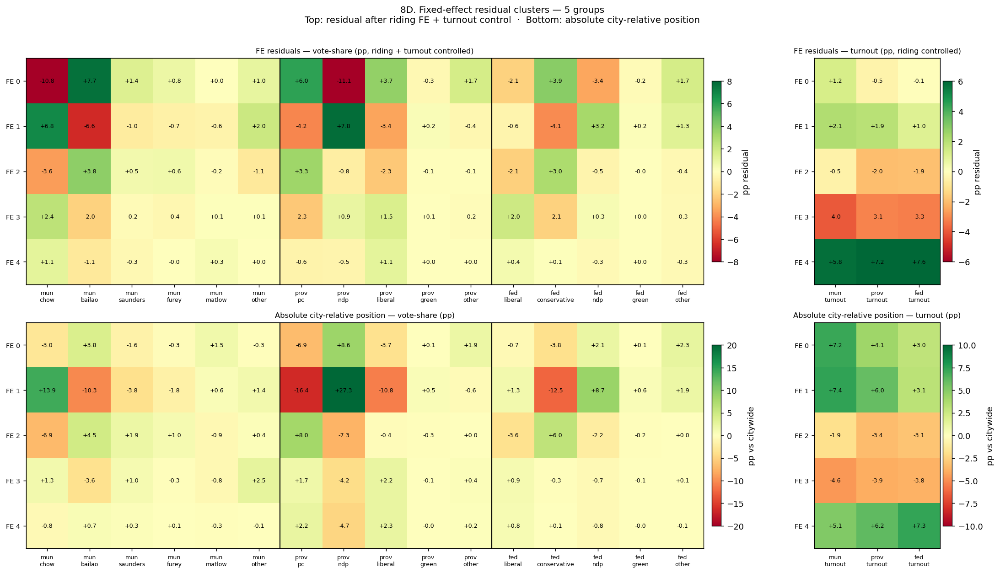

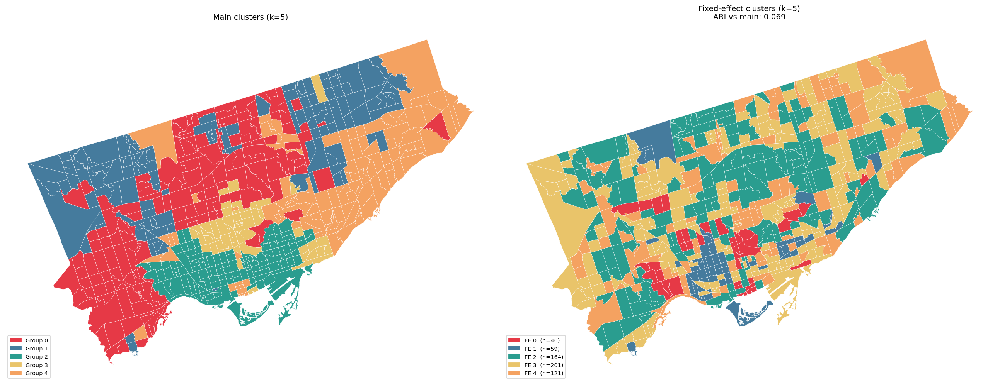

FE Group 0  (40 tracts)  Largest residuals: prov_ndp=-11.1pp, mun_chow=-10.8pp, mun_bailao=+7.7pp, prov_pc=+6.0pp
FE Group 1  (59 tracts)  Largest residuals: prov_ndp=+7.8pp, mun_chow=+6.8pp, mun_bailao=-6.6pp, prov_pc=-4.2pp
FE Group 2  (164 tracts)  Largest residuals: mun_bailao=+3.8pp, mun_chow=-3.6pp, prov_pc=+3.3pp, fed_conservative=+3.0pp
FE Group 3  (201 tracts)  Largest residuals: mun_chow=+2.4pp, prov_pc=-2.3pp, fed_conservative=-2.1pp, mun_bailao=-2.0pp
FE Group 4  (121 tracts)  Largest residuals: mun_bailao=-1.1pp, prov_liberal=+1.1pp, mun_chow=+1.1pp, prov_pc=-0.6pp
Saved: 8d_fe_resid_heatmap.png, 8d_fe_resid_map.png, 8d_fe_resid_profiles.csv


In [30]:
from sklearn.linear_model import LinearRegression

df_fe = raw_gdf[ALL_COLS].copy()
df_fe.index = raw_gdf["ct_id"]
df_fe = df_fe.join(riding_df.set_index("ct_id"))

fe_resid = np.zeros((len(raw_gdf), len(ALL_COLS)), dtype=float)
for j, col in enumerate(ALL_COLS):
    if col.startswith("mun"):
        group_col, turn_col = "mun_riding", "mun_turnout"
    elif col.startswith("prov"):
        group_col, turn_col = "prov_riding", "prov_turnout"
    else:
        group_col, turn_col = "fed_riding", "fed_turnout"
    dummies = pd.get_dummies(df_fe[group_col], drop_first=True).values.astype(float)
    y = df_fe[col].values.astype(float)
    X_reg = np.column_stack([dummies, df_fe[turn_col].values]) if "turnout" not in col else dummies
    fe_resid[:, j] = y - LinearRegression(fit_intercept=True).fit(X_reg, y).predict(X_reg)

fe_labels, fe_sil = cluster_in_pca(fe_resid, ALL_COLS, ELECTION_BLOCKS, K_CHOSEN)
fe_ari = adjusted_rand_score(km_labels_sorted, fe_labels)

fe_cx = np.array([raw_gdf.geometry.centroid.x.values[fe_labels == c].mean() for c in range(K_CHOSEN)])
fe_remap = {old: new for new, old in enumerate(np.argsort(fe_cx))}
fe_labels_sorted = np.array([fe_remap[l] for l in fe_labels])
raw_gdf["cluster_fe"] = fe_labels_sorted
fe_sizes = pd.Series(fe_labels_sorted).value_counts().sort_index()
print(f"8D. Fixed-effect residuals (riding + turnout control, {K_CHOSEN} clusters):")
print(f"  Silhouette: {fe_sil:.4f}   ARI vs main: {fe_ari:.4f}")
print("Cluster sizes:", fe_sizes.to_dict())

fe_resid_df = pd.DataFrame(fe_resid, columns=ALL_COLS, index=raw_gdf["ct_id"])
fe_resid_profiles = pd.DataFrame(
    np.array([fe_resid_df.values[fe_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"FE {c}" for c in range(K_CHOSEN)],
)
fe_abs_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[fe_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"FE {c}" for c in range(K_CHOSEN)],
)

# Heatmap
fig, axes = plt.subplots(2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)

im1 = draw_heatmap(axes[0, 0], fe_resid_profiles, SHARE_COLS,
                   "FE residuals — vote-share (pp, riding + turnout controlled)", vabs=8)
im2 = draw_heatmap(axes[0, 1], fe_resid_profiles, TURNOUT_COLS,
                   "FE residuals — turnout (pp, riding controlled)", vabs=6)
im3 = draw_heatmap(axes[1, 0], fe_abs_profiles, SHARE_COLS,
                   "Absolute city-relative position — vote-share (pp)", vabs=20)
im4 = draw_heatmap(axes[1, 1], fe_abs_profiles, TURNOUT_COLS,
                   "Absolute city-relative position — turnout (pp)", vabs=10)
for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp residual",   shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp residual",   shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs citywide", shrink=0.8, pad=0.02)
fig.suptitle(
    f"8D. Fixed-effect residual clusters — {K_CHOSEN} groups\n"
    "Top: residual after riding FE + turnout control  ·  Bottom: absolute city-relative position",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8d_fe_resid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN})", fontsize=11)
ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
raw_gdf.plot(column="cluster_fe", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Fixed-effect clusters (k={K_CHOSEN})\nARI vs main: {fe_ari:.3f}", fontsize=11)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"FE {c}  (n={fe_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8d_fe_resid_map.png", dpi=150, bbox_inches="tight")
plt.show()

for c in range(K_CHOSEN):
    mask = fe_labels_sorted == c
    row  = fe_resid_profiles.iloc[c]
    top4 = row[SHARE_COLS].abs().nlargest(4).index
    print(f"FE Group {c}  ({mask.sum()} tracts)  "
          "Largest residuals: " + ", ".join(f"{col}={row[col]:+.1f}pp" for col in top4))

_out8d = fe_abs_profiles.copy()
_out8d.insert(0, "n_tracts", [int((fe_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8d.to_csv(EXPLORE_DIR / "8d_fe_resid_profiles.csv")
print("Saved: 8d_fe_resid_heatmap.png, 8d_fe_resid_map.png, 8d_fe_resid_profiles.csv")


## 8E. Context-Adjusted Blended Model (70% City / 30% Riding)

A pure riding-residual model can conflate very different places: a 70% NDP tract and a 20% NDP tract both look the same if both are +10pp relative to their riding. This model preserves both signals simultaneously by concatenating two feature blocks:

- **City-relative block** (α): how each tract compares to the city overall
- **Riding-relative block** (1−α): how each tract compares to its own riding result (vote-weighted)

Both blocks are standardised within each election and scaled α vs (1−α). The same pipeline follows: block weighting → PCA → k-means (k=5). We test α = 0.8, 0.7, 0.5.

In [31]:
def apply_blend_weights(X_city, X_riding, col_names, blocks, alpha):
    """Block-weight city/riding halves independently, then scale by alpha vs (1-alpha)."""
    X_c = np.zeros_like(X_city, dtype=float)
    X_r = np.zeros_like(X_riding, dtype=float)
    for block_cols in blocks.values():
        idx = [col_names.index(c) for c in block_cols]
        n_b = len(idx)
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx])   / np.sqrt(n_b)
        X_r[:, idx] = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(n_b)
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])


X_city_vals   = rel_df[ALL_COLS].values.astype(float)
X_riding_vals = vw_resid_df[ALL_COLS].values.astype(float)
_norm_idx = np.where(~anomaly_mask)[0]

blend_results = {}
print("8E. Blended model comparison:")
for alpha in [0.8, 0.7, 0.5]:
    X_bl = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, alpha)
    pca_full = PCA(n_components=min(15, X_bl.shape[1])).fit(X_bl)
    n90_bl   = int(np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.90)) + 1
    X_pca_bl = PCA(n_components=n90_bl, random_state=RANDOM_STATE).fit_transform(X_bl)
    km_bl    = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
    km_bl.fit(X_pca_bl[_norm_idx])
    labels_bl = _assign_all(km_bl, X_pca_bl, _norm_idx, anomaly_mask)
    sil_bl    = silhouette_score(X_pca_bl[_norm_idx], km_bl.labels_)
    ari_bl    = adjusted_rand_score(km_labels_sorted, labels_bl)
    blend_results[alpha] = {"labels": labels_bl, "sil": sil_bl, "ari": ari_bl, "n90": n90_bl}
    print(f"  alpha={alpha}: sil={sil_bl:.4f}, ARI vs main={ari_bl:.4f}, PCA dims={n90_bl}")

alpha_best = 0.7
blend_labels = blend_results[alpha_best]["labels"]

blend_cx = np.array([raw_gdf.geometry.centroid.x.values[blend_labels == c].mean()
                     for c in range(K_CHOSEN)])
blend_remap = {old: new for new, old in enumerate(np.argsort(blend_cx))}
blend_labels_sorted = np.array([blend_remap[l] for l in blend_labels])
raw_gdf["cluster_blend"] = blend_labels_sorted
blend_sizes = pd.Series(blend_labels_sorted).value_counts().sort_index()
print(f"\nUsing alpha={alpha_best}: {blend_sizes.to_dict()}")
print(f"ARI vs vote-weighted riding model: "
      f"{adjusted_rand_score(vw_labels_sorted, blend_labels_sorted):.4f}")

blend_city_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[blend_labels_sorted == c].mean(axis=0)
              for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"Blend {c}" for c in range(K_CHOSEN)],
)
blend_riding_profiles = pd.DataFrame(
    np.array([vw_resid_df[ALL_COLS].values[blend_labels_sorted == c].mean(axis=0)
              for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"Blend {c}" for c in range(K_CHOSEN)],
)


8E. Blended model comparison:
  alpha=0.8: sil=0.2321, ARI vs main=0.9485, PCA dims=10


  alpha=0.7: sil=0.1930, ARI vs main=0.6322, PCA dims=12


  alpha=0.5: sil=0.1673, ARI vs main=0.4138, PCA dims=14

Using alpha=0.7: {0: 167, 1: 93, 2: 55, 3: 177, 4: 93}
ARI vs vote-weighted riding model: 0.1353


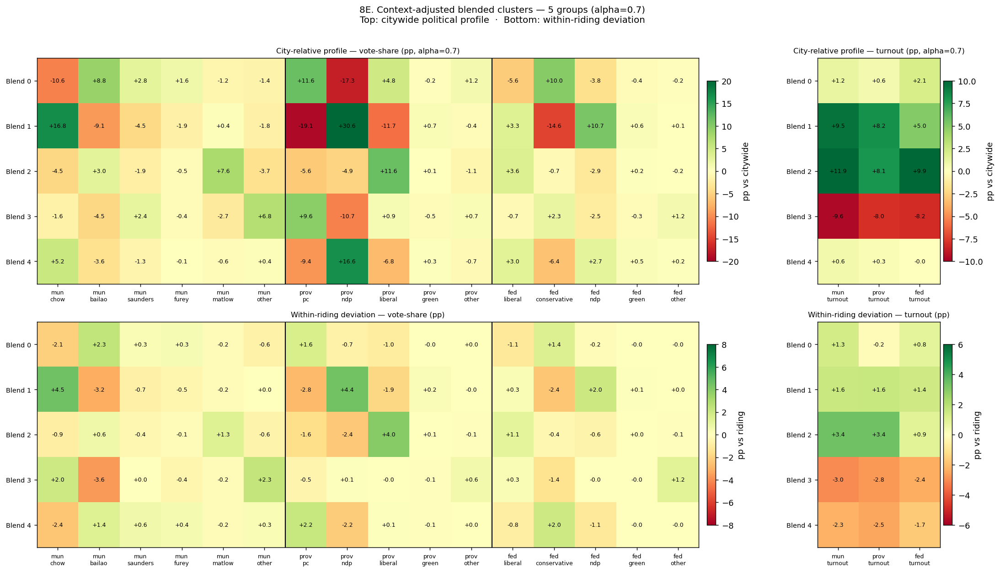

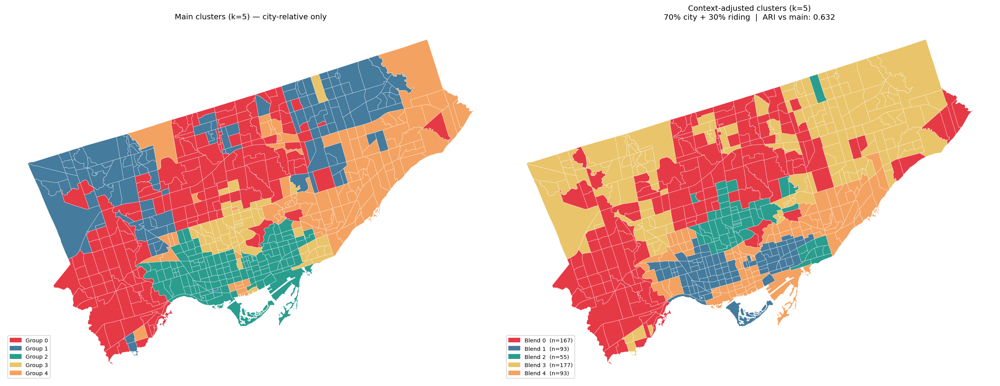

=== 8E. Context-Adjusted Blended Clusters (alpha=0.7, k=5) ===
Blend Group 0  (167 tracts)
  City-relative: prov_ndp=-17.3pp, prov_pc=+11.6pp, mun_chow=-10.6pp
  Within-riding: mun_bailao=+2.3pp, mun_chow=-2.1pp, prov_pc=+1.6pp

Blend Group 1  (93 tracts)
  City-relative: prov_ndp=+30.6pp, prov_pc=-19.1pp, mun_chow=+16.8pp
  Within-riding: mun_chow=+4.5pp, prov_ndp=+4.4pp, mun_bailao=-3.2pp

Blend Group 2  (55 tracts)
  City-relative: prov_liberal=+11.6pp, mun_matlow=+7.6pp, prov_pc=-5.6pp
  Within-riding: prov_liberal=+4.0pp, prov_ndp=-2.4pp, prov_pc=-1.6pp

Blend Group 3  (177 tracts)
  City-relative: prov_ndp=-10.7pp, prov_pc=+9.6pp, mun_other=+6.8pp
  Within-riding: mun_bailao=-3.6pp, mun_other=+2.3pp, mun_chow=+2.0pp

Blend Group 4  (93 tracts)
  City-relative: prov_ndp=+16.6pp, prov_pc=-9.4pp, prov_liberal=-6.8pp
  Within-riding: mun_chow=-2.4pp, prov_ndp=-2.2pp, prov_pc=+2.2pp

Saved: 8e_blend70_heatmap.png, 8e_blend70_map.png, 8e_blend70_profiles.csv


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)

im1 = draw_heatmap(axes[0, 0], blend_city_profiles, SHARE_COLS,
                   f"City-relative profile — vote-share (pp, alpha={alpha_best})", vabs=20)
im2 = draw_heatmap(axes[0, 1], blend_city_profiles, TURNOUT_COLS,
                   f"City-relative profile — turnout (pp, alpha={alpha_best})", vabs=10)
im3 = draw_heatmap(axes[1, 0], blend_riding_profiles, SHARE_COLS,
                   "Within-riding deviation — vote-share (pp)", vabs=8)
im4 = draw_heatmap(axes[1, 1], blend_riding_profiles, TURNOUT_COLS,
                   "Within-riding deviation — turnout (pp)", vabs=6)
for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs citywide", shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs riding",   shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs riding",   shrink=0.8, pad=0.02)
fig.suptitle(
    f"8E. Context-adjusted blended clusters — {K_CHOSEN} groups (alpha={alpha_best})\n"
    "Top: citywide political profile  ·  Bottom: within-riding deviation",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8e_blend70_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN}) — city-relative only", fontsize=11)
ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
raw_gdf.plot(column="cluster_blend", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(
    f"Context-adjusted clusters (k={K_CHOSEN})\n"
    f"70% city + 30% riding  |  ARI vs main: {blend_results[alpha_best]['ari']:.3f}",
    fontsize=11,
)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Blend {c}  (n={blend_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8e_blend70_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"=== 8E. Context-Adjusted Blended Clusters (alpha={alpha_best}, k={K_CHOSEN}) ===")
for c in range(K_CHOSEN):
    mask = blend_labels_sorted == c
    cp   = blend_city_profiles.iloc[c]
    rp   = blend_riding_profiles.iloc[c]
    top3c = cp[SHARE_COLS].abs().nlargest(3).index
    top3r = rp[SHARE_COLS].abs().nlargest(3).index
    print(f"Blend Group {c}  ({mask.sum()} tracts)")
    print(f"  City-relative: " + ", ".join(f"{col}={cp[col]:+.1f}pp" for col in top3c))
    print(f"  Within-riding: " + ", ".join(f"{col}={rp[col]:+.1f}pp" for col in top3r))
    print()

_out8e = blend_city_profiles.copy()
_out8e.insert(0, "n_tracts", [int((blend_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8e.to_csv(EXPLORE_DIR / "8e_blend70_profiles.csv")
print("Saved: 8e_blend70_heatmap.png, 8e_blend70_map.png, 8e_blend70_profiles.csv")


## 8F. Blended 50/50 Model

Equal weighting of citywide and riding-relative signals. Midpoint between the main model (100% city-relative) and a pure riding-residual model.

8F. Blended 50/50: sil=0.1673, ARI vs main=0.4138
Cluster sizes: {0: 129, 1: 108, 2: 85, 3: 77, 4: 186}


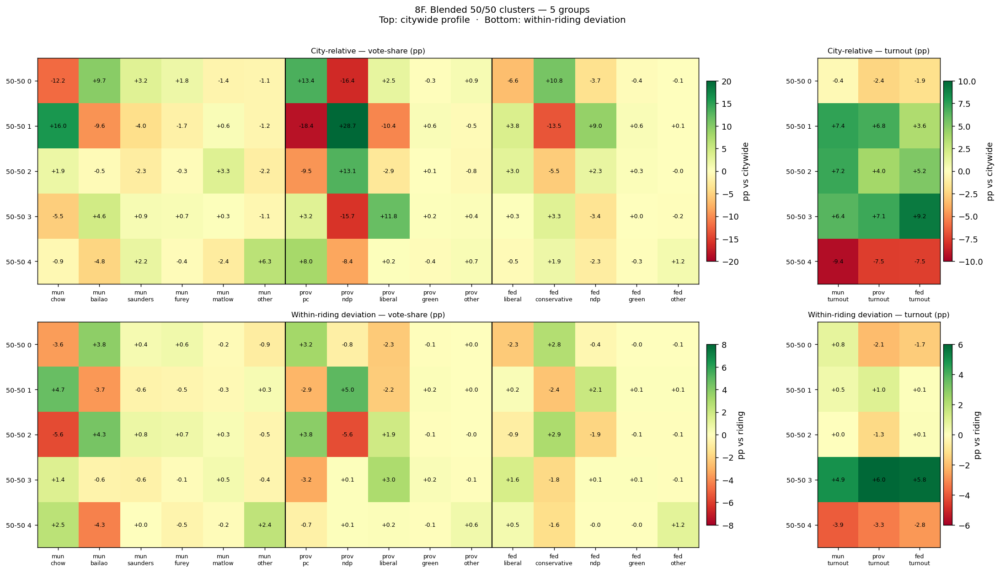

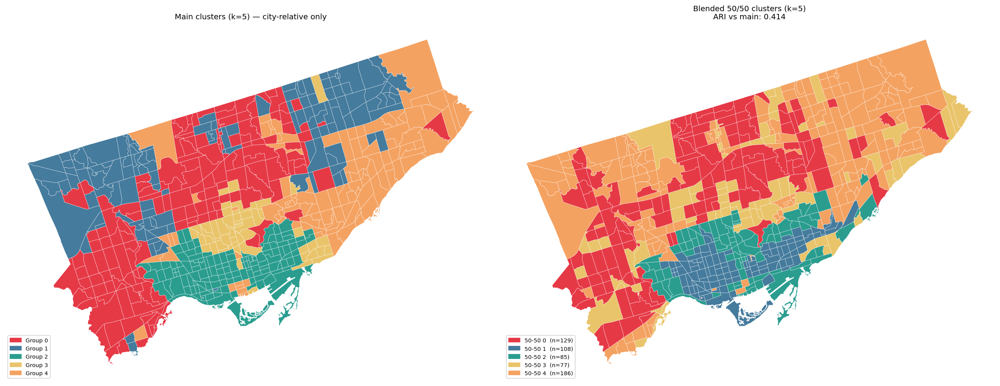

Saved: 8f_blend50_heatmap.png, 8f_blend50_map.png, 8f_blend50_profiles.csv


In [33]:
alpha_f  = 0.5
f_labels = blend_results[alpha_f]["labels"]
f_ari    = blend_results[alpha_f]["ari"]
f_sil    = blend_results[alpha_f]["sil"]

f_cx    = np.array([raw_gdf.geometry.centroid.x.values[f_labels == c].mean() for c in range(K_CHOSEN)])
f_remap = {old: new for new, old in enumerate(np.argsort(f_cx))}
f_labels_sorted = np.array([f_remap[l] for l in f_labels])
raw_gdf["cluster_blend50"] = f_labels_sorted
f_sizes = pd.Series(f_labels_sorted).value_counts().sort_index()
print(f"8F. Blended 50/50: sil={f_sil:.4f}, ARI vs main={f_ari:.4f}")
print("Cluster sizes:", f_sizes.to_dict())

f_city_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[f_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)
f_riding_profiles = pd.DataFrame(
    np.array([vw_resid_df[ALL_COLS].values[f_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)

fig, axes = plt.subplots(2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)
im1 = draw_heatmap(axes[0, 0], f_city_profiles, SHARE_COLS, "City-relative — vote-share (pp)", vabs=20)
im2 = draw_heatmap(axes[0, 1], f_city_profiles, TURNOUT_COLS, "City-relative — turnout (pp)", vabs=10)
im3 = draw_heatmap(axes[1, 0], f_riding_profiles, SHARE_COLS, "Within-riding deviation — vote-share (pp)", vabs=8)
im4 = draw_heatmap(axes[1, 1], f_riding_profiles, TURNOUT_COLS, "Within-riding deviation — turnout (pp)", vabs=6)
for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs citywide", shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs riding",   shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs riding",   shrink=0.8, pad=0.02)
fig.suptitle(f"8F. Blended 50/50 clusters — {K_CHOSEN} groups\n"
             "Top: citywide profile  ·  Bottom: within-riding deviation", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8f_blend50_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN}) — city-relative only", fontsize=11); ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
raw_gdf.plot(column="cluster_blend50", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Blended 50/50 clusters (k={K_CHOSEN})\nARI vs main: {f_ari:.3f}", fontsize=11)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"50-50 {c}  (n={f_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8f_blend50_map.png", dpi=150, bbox_inches="tight")
plt.show()

_out8f = f_city_profiles.copy()
_out8f.insert(0, "n_tracts", [int((f_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8f.to_csv(EXPLORE_DIR / "8f_blend50_profiles.csv")
print("Saved: 8f_blend50_heatmap.png, 8f_blend50_map.png, 8f_blend50_profiles.csv")


## 8G. Blended 30/70 Model

30% city-relative, 70% riding-relative. At this weighting the within-riding signal dominates; clusters reflect local distinctiveness anchored lightly to the city-wide spectrum.

8G. Blended 30/70: sil=0.1346, ARI vs main=0.1570, PCA dims=13
Cluster sizes: {0: 129, 1: 36, 2: 80, 3: 199, 4: 141}


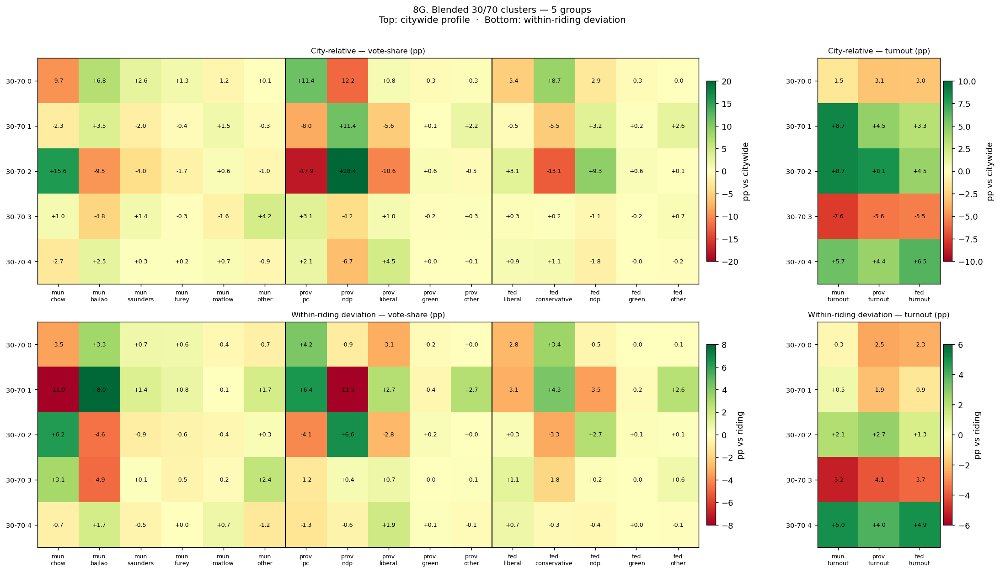

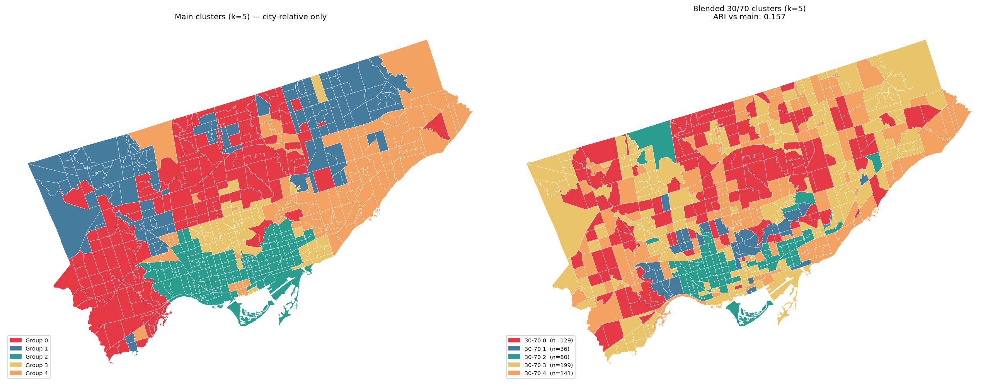

Saved: 8g_blend30_heatmap.png, 8g_blend30_map.png, 8g_blend30_profiles.csv


In [34]:
alpha_g  = 0.3
X_bl_g   = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, alpha_g)
pca_g    = PCA(n_components=min(15, X_bl_g.shape[1])).fit(X_bl_g)
n90_g    = int(np.searchsorted(np.cumsum(pca_g.explained_variance_ratio_), 0.90)) + 1
X_pca_g  = PCA(n_components=n90_g, random_state=RANDOM_STATE).fit_transform(X_bl_g)
km_g     = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE).fit(X_pca_g[_norm_idx])
g_labels = _assign_all(km_g, X_pca_g, _norm_idx, anomaly_mask)
g_sil    = silhouette_score(X_pca_g[_norm_idx], km_g.labels_)
g_ari    = adjusted_rand_score(km_labels_sorted, g_labels)
print(f"8G. Blended 30/70: sil={g_sil:.4f}, ARI vs main={g_ari:.4f}, PCA dims={n90_g}")

g_cx    = np.array([raw_gdf.geometry.centroid.x.values[g_labels == c].mean() for c in range(K_CHOSEN)])
g_remap = {old: new for new, old in enumerate(np.argsort(g_cx))}
g_labels_sorted = np.array([g_remap[l] for l in g_labels])
raw_gdf["cluster_blend30"] = g_labels_sorted
g_sizes = pd.Series(g_labels_sorted).value_counts().sort_index()
print("Cluster sizes:", g_sizes.to_dict())

g_city_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[g_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"30-70 {c}" for c in range(K_CHOSEN)],
)
g_riding_profiles = pd.DataFrame(
    np.array([vw_resid_df[ALL_COLS].values[g_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"30-70 {c}" for c in range(K_CHOSEN)],
)

fig, axes = plt.subplots(2, 2, figsize=(17, 6 + K_CHOSEN * 0.7),
    gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)
im1 = draw_heatmap(axes[0, 0], g_city_profiles, SHARE_COLS, "City-relative — vote-share (pp)", vabs=20)
im2 = draw_heatmap(axes[0, 1], g_city_profiles, TURNOUT_COLS, "City-relative — turnout (pp)", vabs=10)
im3 = draw_heatmap(axes[1, 0], g_riding_profiles, SHARE_COLS, "Within-riding deviation — vote-share (pp)", vabs=8)
im4 = draw_heatmap(axes[1, 1], g_riding_profiles, TURNOUT_COLS, "Within-riding deviation — turnout (pp)", vabs=6)
for row_ax in axes:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        row_ax[0].axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs citywide", shrink=0.8, pad=0.01)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs citywide", shrink=0.8, pad=0.02)
fig.colorbar(im3, ax=axes[1, 0], label="pp vs riding",   shrink=0.8, pad=0.01)
fig.colorbar(im4, ax=axes[1, 1], label="pp vs riding",   shrink=0.8, pad=0.02)
fig.suptitle(f"8G. Blended 30/70 clusters — {K_CHOSEN} groups\n"
             "Top: citywide profile  ·  Bottom: within-riding deviation", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8g_blend30_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
_cmap = mcolors.ListedColormap(PALETTE[:K_CHOSEN])
raw_gdf.plot(column="cluster", ax=ax1, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax1.set_title(f"Main clusters (k={K_CHOSEN}) — city-relative only", fontsize=11); ax1.axis("off")
ax1.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"Group {c}")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
raw_gdf.plot(column="cluster_blend30", ax=ax2, categorical=True,
             cmap=_cmap, edgecolor="white", linewidth=0.3, legend=False)
ax2.set_title(f"Blended 30/70 clusters (k={K_CHOSEN})\nARI vs main: {g_ari:.3f}", fontsize=11)
ax2.axis("off")
ax2.legend(handles=[mpatches.Patch(color=PALETTE[c], label=f"30-70 {c}  (n={g_sizes.get(c, 0)})")
                    for c in range(K_CHOSEN)], loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(EXPLORE_DIR / "8g_blend30_map.png", dpi=150, bbox_inches="tight")
plt.show()

_out8g = g_city_profiles.copy()
_out8g.insert(0, "n_tracts", [int((g_labels_sorted == c).sum()) for c in range(K_CHOSEN)])
_out8g.to_csv(EXPLORE_DIR / "8g_blend30_profiles.csv")
print("Saved: 8g_blend30_heatmap.png, 8g_blend30_map.png, 8g_blend30_profiles.csv")


## 9. Extended Exploration Under the Blended 50/50 Model

Section 8F's 50/50 blend (equal city-relative / within-riding-relative weighting) is the
adopted model going forward. Two follow-up checks, both run under that model:

1. **Cluster-count sensitivity** — how do the groups, and their silhouette scores, change
   across k = 3, 4, 5, 6, 7?
2. **Down-weighting a suspected idiosyncratic result** — cluster 2 partly emerges from a
   pronounced Matlow showing in specific 2023 municipal results. That signal lives in the
   **riding-relative (within-riding) block** — the half of the blend meant to capture local
   deviations rather than durable, citywide-comparable patterns. We test what happens if we
   shrink Matlow's contribution to that block specifically, i.e. treat it more as a one-off
   local-conditions effect than an entrenched voting pattern.


### 9A. Cluster-Count Sensitivity (Blended 50/50)

Same PCA embedding (block-weighted, α=0.5 city/riding blend, ≥90% variance) used throughout
§8F, re-clustered at k = 3, 4, 5, 6, 7. Cluster IDs are re-sorted west→east for each k
independently, as elsewhere in this notebook.


In [35]:
# PCA embedding for the 50/50 blend (identical construction to §8F / blend_results[0.5])
alpha_50 = 0.5
X_bl_50   = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, alpha_50)
pca_50    = PCA(n_components=min(15, X_bl_50.shape[1])).fit(X_bl_50)
n90_50    = int(np.searchsorted(np.cumsum(pca_50.explained_variance_ratio_), 0.90)) + 1
X_pca_50  = PCA(n_components=n90_50, random_state=RANDOM_STATE).fit_transform(X_bl_50)
print(f"Blended 50/50 PCA embedding: {n90_50} components (>=90% variance)")

K_RANGE_9A = [3, 4, 5, 6, 7]
blend50_by_k = {}
rows_9a = []
for k in tqdm(K_RANGE_9A, desc="Blended 50/50 -- k sweep"):
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_pca_50[_norm_idx])
    labels_k = _assign_all(km, X_pca_50, _norm_idx, anomaly_mask)
    sil_k    = silhouette_score(X_pca_50[_norm_idx], km.labels_)

    cx      = np.array([raw_gdf.geometry.centroid.x.values[labels_k == c].mean() for c in range(k)])
    remap_k = {old: new for new, old in enumerate(np.argsort(cx))}
    labels_sorted_k = np.array([remap_k[l] for l in labels_k])

    blend50_by_k[k] = {"labels": labels_sorted_k, "sil": sil_k}
    sizes_k = pd.Series(labels_sorted_k).value_counts().sort_index()
    rows_9a.append({"k": k, "Silhouette": round(sil_k, 4), "n_tracts_per_cluster": sizes_k.to_dict()})

sil_9a_df = pd.DataFrame(rows_9a)
print("=== 9A. Blended 50/50 -- silhouette by k ===")
print(sil_9a_df.to_string(index=False))
sil_9a_df.to_csv(EXPLORE_DIR / "9a_blend50_k_sweep_silhouette.csv", index=False)
print("\nSaved 9a_blend50_k_sweep_silhouette.csv to explore/")


Blended 50/50 PCA embedding: 14 components (>=90% variance)


Blended 50/50 -- k sweep:   0%|          | 0/5 [00:00<?, ?it/s]

=== 9A. Blended 50/50 -- silhouette by k ===
 k  Silhouette                                n_tracts_per_cluster
 3      0.1667                            {0: 190, 1: 173, 2: 222}
 4      0.1657                    {0: 144, 1: 106, 2: 218, 3: 117}
 5      0.1673              {0: 129, 1: 108, 2: 85, 3: 77, 4: 186}
 6      0.1475        {0: 130, 1: 74, 2: 42, 3: 74, 4: 176, 5: 89}
 7      0.1373 {0: 102, 1: 60, 2: 91, 3: 43, 4: 162, 5: 42, 6: 85}

Saved 9a_blend50_k_sweep_silhouette.csv to explore/


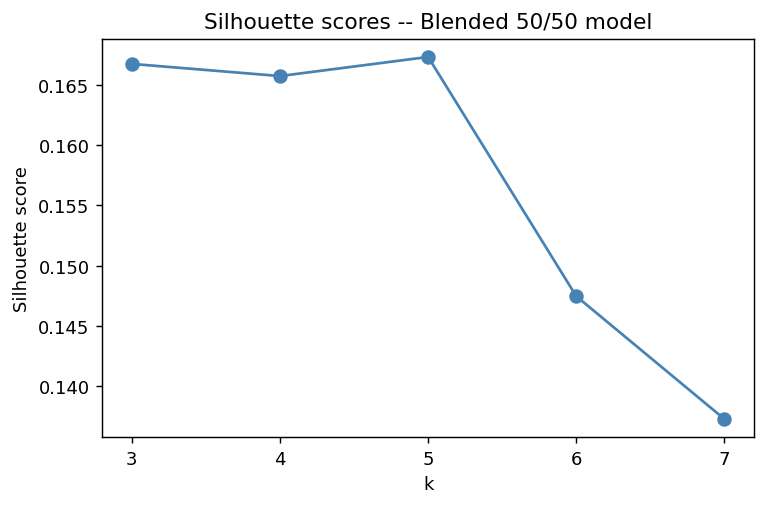

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(K_RANGE_9A, [blend50_by_k[k]["sil"] for k in K_RANGE_9A],
        marker="o", color="steelblue", ms=7)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_xticks(K_RANGE_9A)
ax.set_title("Silhouette scores -- Blended 50/50 model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "9a_blend50_k_sweep_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading the table.** The 50/50 blend's silhouette scores are noticeably lower than the
base city-relative model's (§4) at every k -- expected, since blending in within-riding
residuals adds a second, weaker-signal axis that K-means has to reconcile with the first.
The map grid below shows the **blended clusters only** (not the main city-relative clusters)
for each k, so the groupings can be read on their own terms.


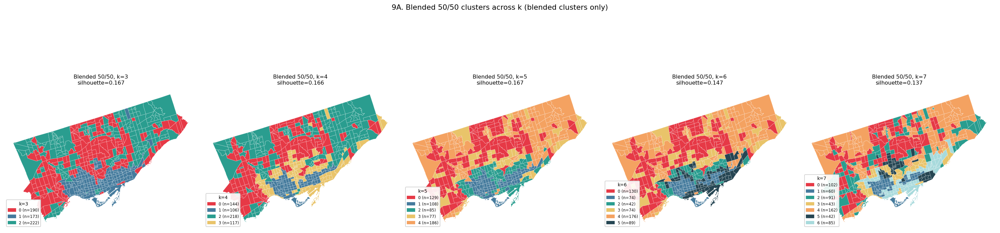

In [37]:
fig, axes = plt.subplots(1, len(K_RANGE_9A), figsize=(4.6 * len(K_RANGE_9A), 6.5))
for ax, k in zip(axes, K_RANGE_9A):
    labels_sorted_k = blend50_by_k[k]["labels"]
    cmap_k = mcolors.ListedColormap(PALETTE[:k])
    plot_gdf = raw_gdf[["geometry"]].copy()
    plot_gdf["_cluster"] = labels_sorted_k
    plot_gdf.plot(column="_cluster", ax=ax, categorical=True, cmap=cmap_k,
                  edgecolor="white", linewidth=0.2, legend=False)
    sizes_k = pd.Series(labels_sorted_k).value_counts().sort_index()
    ax.legend(
        handles=[mpatches.Patch(color=PALETTE[c], label=f"{c} (n={sizes_k.get(c, 0)})") for c in range(k)],
        loc="lower left", fontsize=6.5, title=f"k={k}", title_fontsize=7.5, framealpha=0.9,
    )
    ax.set_title(f"Blended 50/50, k={k}\nsilhouette={blend50_by_k[k]['sil']:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle("9A. Blended 50/50 clusters across k (blended clusters only)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "9a_blend50_k_sweep_maps.png", dpi=200, bbox_inches="tight")
plt.show()


### 9B. Down-Weighting Matlow's Within-Riding Signal

Cluster 2 in the main model is disproportionately shaped by tracts where Josh Matlow ran far
ahead of his citywide share -- concentrated in and around his home riding. That pattern shows
up in the **riding-relative block**, i.e. as a deviation from the riding's own result, which is
exactly the block meant to capture "local conditions" rather than a durable political
alignment. Below we shrink `mun_matlow`'s standardised contribution to that block to 20% of
its normal scale (leaving the city-relative block, and every other candidate/party, untouched)
and re-run the 50/50 blend at k = 4, 5, 6.


In [38]:
def apply_blend_weights_damped(X_city, X_riding, col_names, blocks, alpha, damp_col, damp_factor):
    """Same as apply_blend_weights, but shrinks one column's contribution within the
    riding-relative (local-deviation) block by damp_factor after standardisation. Used to test
    whether a pronounced local result (e.g. Matlow's municipal vote) is driving a cluster split
    because it reflects a genuine entrenched pattern, or an idiosyncratic local-conditions
    effect the model may be over-weighting."""
    X_c = np.zeros_like(X_city, dtype=float)
    X_r = np.zeros_like(X_riding, dtype=float)
    damp_idx = col_names.index(damp_col)
    for block_cols in blocks.values():
        idx = [col_names.index(c) for c in block_cols]
        n_b = len(idx)
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx]) / np.sqrt(n_b)
        X_r_block   = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(n_b)
        if damp_idx in idx:
            X_r_block[:, idx.index(damp_idx)] *= damp_factor
        X_r[:, idx] = X_r_block
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])

MATLOW_DAMP_FACTOR = 0.2  # shrink Matlow's within-riding deviation to 20% of its standardised scale
X_bl_9b  = apply_blend_weights_damped(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS,
                                       alpha_50, "mun_matlow", MATLOW_DAMP_FACTOR)
pca_9b   = PCA(n_components=min(15, X_bl_9b.shape[1])).fit(X_bl_9b)
n90_9b   = int(np.searchsorted(np.cumsum(pca_9b.explained_variance_ratio_), 0.90)) + 1
X_pca_9b = PCA(n_components=n90_9b, random_state=RANDOM_STATE).fit_transform(X_bl_9b)
print(f"Matlow-damped blend PCA embedding: {n90_9b} components (>=90% variance)")

K_RANGE_9B = [4, 5, 6]
blend50_damped_by_k = {}
rows_9b = []
for k in tqdm(K_RANGE_9B, desc="Blended 50/50, Matlow-damped -- k sweep"):
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    km.fit(X_pca_9b[_norm_idx])
    labels_k = _assign_all(km, X_pca_9b, _norm_idx, anomaly_mask)
    sil_k    = silhouette_score(X_pca_9b[_norm_idx], km.labels_)

    cx      = np.array([raw_gdf.geometry.centroid.x.values[labels_k == c].mean() for c in range(k)])
    remap_k = {old: new for new, old in enumerate(np.argsort(cx))}
    labels_sorted_k = np.array([remap_k[l] for l in labels_k])

    ari_vs_undamped = adjusted_rand_score(blend50_by_k[k]["labels"], labels_sorted_k)
    blend50_damped_by_k[k] = {"labels": labels_sorted_k, "sil": sil_k, "ari_vs_undamped": ari_vs_undamped}
    sizes_k = pd.Series(labels_sorted_k).value_counts().sort_index()
    rows_9b.append({
        "k": k, "Silhouette": round(sil_k, 4),
        "ARI vs undamped 50/50": round(ari_vs_undamped, 4),
        "n_tracts_per_cluster": sizes_k.to_dict(),
    })

sil_9b_df = pd.DataFrame(rows_9b)
print(f"=== 9B. Blended 50/50, Matlow within-riding deviation damped to {MATLOW_DAMP_FACTOR:.0%} ===")
print(sil_9b_df.to_string(index=False))
sil_9b_df.to_csv(EXPLORE_DIR / "9b_blend50_matlow_damped_k_sweep_silhouette.csv", index=False)
print("\nSaved 9b_blend50_matlow_damped_k_sweep_silhouette.csv to explore/")


Matlow-damped blend PCA embedding: 14 components (>=90% variance)


Blended 50/50, Matlow-damped -- k sweep:   0%|          | 0/3 [00:00<?, ?it/s]

=== 9B. Blended 50/50, Matlow within-riding deviation damped to 20% ===
 k  Silhouette  ARI vs undamped 50/50                         n_tracts_per_cluster
 4      0.1642                 0.7677             {0: 172, 1: 108, 2: 105, 3: 200}
 5      0.1699                 0.9947       {0: 130, 1: 108, 2: 85, 3: 77, 4: 185}
 6      0.1464                 0.9171 {0: 130, 1: 70, 2: 44, 3: 77, 4: 174, 5: 90}

Saved 9b_blend50_matlow_damped_k_sweep_silhouette.csv to explore/


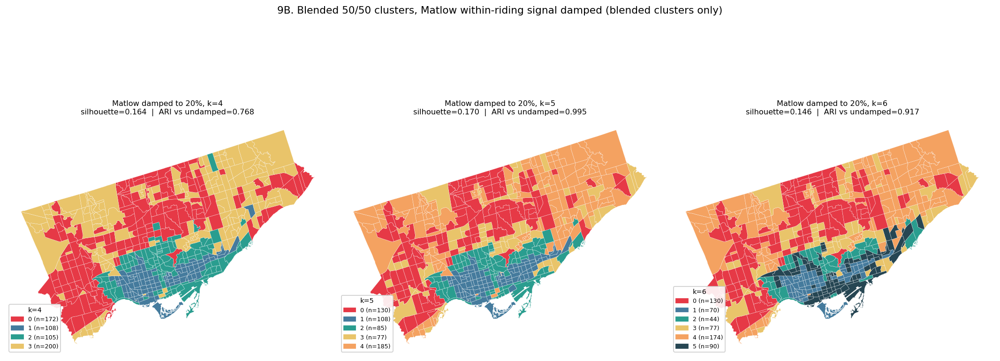

In [39]:
fig, axes = plt.subplots(1, len(K_RANGE_9B), figsize=(5.5 * len(K_RANGE_9B), 7))
for ax, k in zip(axes, K_RANGE_9B):
    labels_sorted_k = blend50_damped_by_k[k]["labels"]
    cmap_k = mcolors.ListedColormap(PALETTE[:k])
    plot_gdf = raw_gdf[["geometry"]].copy()
    plot_gdf["_cluster"] = labels_sorted_k
    plot_gdf.plot(column="_cluster", ax=ax, categorical=True, cmap=cmap_k,
                  edgecolor="white", linewidth=0.2, legend=False)
    sizes_k = pd.Series(labels_sorted_k).value_counts().sort_index()
    ax.legend(
        handles=[mpatches.Patch(color=PALETTE[c], label=f"{c} (n={sizes_k.get(c, 0)})") for c in range(k)],
        loc="lower left", fontsize=7, title=f"k={k}", title_fontsize=8, framealpha=0.9,
    )
    ax.set_title(
        f"Matlow damped to {MATLOW_DAMP_FACTOR:.0%}, k={k}\n"
        f"silhouette={blend50_damped_by_k[k]['sil']:.3f}  |  ARI vs undamped={blend50_damped_by_k[k]['ari_vs_undamped']:.3f}",
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle("9B. Blended 50/50 clusters, Matlow within-riding signal damped (blended clusters only)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "9b_blend50_matlow_damped_maps.png", dpi=200, bbox_inches="tight")
plt.show()


**Direct comparison at k=5** (matching the adopted §8F model): does damping Matlow's
within-riding signal collapse the group it was implicated in, and where does its citywide
`mun_matlow` deviation land afterwards?


In [40]:
cmp_rows = []
for model_name, lbls in [("Undamped 50/50", blend50_by_k[5]["labels"]),
                         (f"Matlow-damped ({MATLOW_DAMP_FACTOR:.0%}) 50/50", blend50_damped_by_k[5]["labels"])]:
    for c in range(5):
        mask = lbls == c
        cmp_rows.append({
            "Model": model_name,
            "Group": c,
            "n_tracts": int(mask.sum()),
            "mun_matlow (pp vs city)": round(rel_df["mun_matlow"].values[mask].mean() * 100, 2),
        })
cmp_df = pd.DataFrame(cmp_rows)
print("=== Matlow city-relative deviation by cluster: undamped vs damped (k=5) ===")
print(cmp_df.to_string(index=False))
cmp_df.to_csv(EXPLORE_DIR / "9b_matlow_damping_cluster_comparison_k5.csv", index=False)
print("\nSaved 9b_matlow_damping_cluster_comparison_k5.csv to explore/")


=== Matlow city-relative deviation by cluster: undamped vs damped (k=5) ===
                    Model  Group  n_tracts  mun_matlow (pp vs city)
           Undamped 50/50      0       129                    -1.38
           Undamped 50/50      1       108                     0.59
           Undamped 50/50      2        85                     3.32
           Undamped 50/50      3        77                     0.28
           Undamped 50/50      4       186                    -2.45
Matlow-damped (20%) 50/50      0       130                    -1.34
Matlow-damped (20%) 50/50      1       108                     0.59
Matlow-damped (20%) 50/50      2        85                     3.32
Matlow-damped (20%) 50/50      3        77                     0.28
Matlow-damped (20%) 50/50      4       185                    -2.48

Saved 9b_matlow_damping_cluster_comparison_k5.csv to explore/


## 10. Saving Model 8F for Downstream Notebooks

Model 8F (§8F above, `alpha=0.5`) is the adopted model, but nothing above has written its
**tract-level** assignment to disk -- only the aggregate `8f_blend50_profiles.csv` (cluster
means and sizes). `explore_clusters_makeup.ipynb` and `process_ct_to_cluster.ipynb` used to
each work around that gap by re-running §1-§8F's feature-engineering, block-weighting,
blending, PCA, and k-means from scratch -- identical code, copy-pasted twice more, purely to
recover the one thing this notebook never saved: `ct_id -> cluster_8f`.

We close that gap here instead: save one table with the 8F cluster assignment, every raw /
city-relative / within-riding feature, and each tract's riding assignments, keyed by `ct_id`.
`03_cluster_interpretation.ipynb` and `04_process_ct_to_cluster.ipynb` both load this file
directly and verify it against `8f_blend50_profiles.csv` themselves -- neither re-fits anything.

In [41]:
# ── Canonical Model 8F tract-level output ─────────────────────────────────────
# cluster_8f: Model 8F's raw cluster ID (§8F), fixed by west→east centroid order, exactly as
# `cluster_blend50` above -- renamed here to `cluster_8f` since that's the name both downstream
# notebooks already use for it.
ct_model_8f = raw_gdf[["ct_id", "geometry"] + ALL_COLS].copy()
ct_model_8f["cluster_8f"] = f_labels_sorted
ct_model_8f["is_anomalous"] = anomaly_mask   # excluded from k-means fitting; see §1

ct_model_8f = ct_model_8f.merge(riding_df, on="ct_id", how="left")
ct_model_8f["ward_label"] = "Ward " + ct_model_8f["mun_riding"].astype(int).astype(str)

rel_named = rel_df.add_suffix("_vs_city").reset_index()
vw_named  = vw_resid_df.add_suffix("_vs_riding").reset_index()
ct_model_8f = ct_model_8f.merge(rel_named, on="ct_id", how="left").merge(vw_named, on="ct_id", how="left")

assert ct_model_8f["ct_id"].duplicated().sum() == 0, "Duplicate ct_id in the canonical output."
assert ct_model_8f["cluster_8f"].notna().all(), "Every tract must have a Model 8F cluster assignment."

# QA: this table's own cluster-level profile should match §8F's `_out8f` / `8f_blend50_profiles.csv`
# exactly, since it is built from the same `rel_df` and `f_labels_sorted` computed above -- not a
# new computation, just a wider save of one already-computed result.
recheck = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[f_labels_sorted == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=range(K_CHOSEN),
)
max_diff_vs_8f_output = np.abs(recheck.values - _out8f[ALL_COLS].values).max()
assert max_diff_vs_8f_output < 1e-9, "Canonical output does not match §8F's own profile -- stop and investigate."

ct_model_8f.drop(columns="geometry").to_csv(PROFILES_DIR / "ct_model_8f.csv", index=False)
gpd.GeoDataFrame(ct_model_8f, geometry="geometry", crs=raw_gdf.crs).to_file(
    PROFILES_DIR / "ct_model_8f.geojson", driver="GeoJSON"
)
print(f"Saved ct_model_8f.csv + .geojson: {ct_model_8f.shape[0]} tracts x {ct_model_8f.shape[1]} columns")
print(f"Cluster sizes (raw ID, west->east): {pd.Series(f_labels_sorted).value_counts().sort_index().to_dict()}")

Saved ct_model_8f.csv + .geojson: 585 tracts x 65 columns
Cluster sizes (raw ID, west->east): {0: 129, 1: 108, 2: 85, 3: 77, 4: 186}


## 11. Next Steps

These were open questions the first time this search was run; each is now answered
elsewhere rather than left as a TODO here:

- **Naming the groups** and **joining census demographics** happen in
  `03_cluster_interpretation.ipynb`, using the tract-level Model 8F file saved in §10 above.
- **k was tuned** to 5 (§4's silhouette sweep, cross-checked under the adopted 50/50 blend in
  §9A) and is fixed as `K_CHOSEN` in the constants cell at the top of this notebook.
- **The riding-residual result was interpreted** in §6-§9: ARI is well above 0 (riding effects
  are not the primary driver; see §6), and the 50/50 blend adopted as Model 8F is exactly the
  response to that finding -- it keeps both the citywide and within-riding signal rather than
  discarding either.
- **Spatial autocorrelation / Moran's I** was not pursued -- the riding-residual and
  spatial-neighbour-residual checks (§6, §8C) already test geographic dependence directly and
  more specifically than a global Moran's I would, so a separate autocorrelation statistic
  would not add a new answer.
- **Stability / boundary cases**: addressed in `03_cluster_interpretation.ipynb` §10
  (“Representative and Boundary Tracts”), which uses PCA-space distance to each tract's own
  vs. nearest-other cluster centroid -- a direct, one-shot measure of exactly which tracts are
  boundary cases, rather than a 100-draw bootstrap approximating the same thing.